# Final Project
#### Team: Arjun Narasimhan & Leon Katarzynski

## Design (04/08/2026)

## 1. Problem and Content

I think we all still experience the same thing: Going to the Science Center, searching for a room, the post office or where again is HUIT? The Science Center is an enormous building, hosting shops, classrooms, labs, in between administrative office and somewhere there, whether in the 8th floor or in the basement, a classroom that you need to find at some point (I did actually come late to my classes because I did not know that there is a classroom in the underground floor!)
However, Google Maps stops at the front door, yet that is where the building becomes confusing. 

Our Final Project solves this with an interactive indoor map. When a user enters the building, the app detects the transition via GPS geofence and switches from outdoor Google Maps routing to a searchable floor-plan view. The user can search for any room, office, or amenity (e.g. *"vending machine"*, *"Room 301"*) and the app highlights a walking path to that destination across floors.

This notebook documents the first steps in the the search and path-finding logic, implemented in Python as a prototype before it is ported to the JavaScript frontend. While we requested access to the official floor plans of the Science Center, we did not receive any response yet. Therefore, the following script works with a default building, roughly sketched to illustrate the method of our code. 

## 2. Approach and Content

The problem decomposes into two sub-problems:

1. **Search** — the user inputs the room, amenity etc. into the search bar.
2. **Path-finding** — given the user's input, the code returns the fastest way to arrive the desired destination.

## 3. Data Structures

The key insight: **the building is a graph.** Rooms are nodes. Two rooms share an edge if a student can walk directly from one to the other without passing through a third room. Stairwells are special nodes whose edges cross between floors — this is how the algorithm knows to go *up* to reach a room on floor 2 from floor 1.

## 4. Algorithm: Breadth-First Search

Finding the shortest path between two rooms is an instance of **shortest path on an unweighted graph**, which is solved optimally by **BFS**. BFS explores nodes layer by layer: first all rooms 1 hop away, then 2 hops away, and so on. Because every step has equal cost, the first time BFS reaches the target it has found the path with the fewest hops.

## 5. Demo Code

### 5.1 Default building


As pointed out in the introduction, we yet do not have access to the Science Center Floor Plan data. Therefore, the following code sketches a default building with three floors in the JSON schema we hope to use for the actual Science Center map.

In [1]:
# Schema overview:
# - Each room has a unique "id", a  "name", a "type", floor number,
#   pixel coordinates within the picture/map, a "neighbors" list of directly connected
#   room ids (meaning you can enter one room through the other), and an optional "description"
#   (f.e. containig whether it is a class room, has any unique features, etc.).
# - Stairwells on adjacent floors count each other as neighbors, allowing BFS to identify them
#   as identical (different floor but same stairwell)
# - Amenity rooms use "amenitySubtype" (e.g., "vending", "restroom").
#
# Floor layout::
#
#   FLOOR 1: sc-101, sc-102, sc-103, sc-rest-1, sc-stair-1
#   FLOOR 2: sc-stair-1, sc-stair-2
#            sc-stair-2, sc-201, sc-202
#   FLOOR 3: sc-stair-2, sc-stair-3
#            sc-stair-3, sc-301, sc-302, sc-vend-1
#
# pixelCoords give each room an (x, y) position on a coordinate system of the floor plan
# Stairwells stack at the same (x, y) across floors, reflecting real buildings.

SAMPLE_BUILDING: dict = {
    "buildingId": "science-center",
    "name": "Harvard Science Center (Sample)",
    "location": {"lat": 42.37652, "lng": -71.11639},
    "floors": [
        {
            "floorNumber": 1,
            "label": "Ground Floor",
            "rooms": [
                {
                    "id": "sc-101",
                    "name": "Lecture Hall A",
                    "type": "lecture",
                    "floor": 1,
                    "pixelCoords": {"x": 100, "y": 120},
                    "neighbors": ["sc-102"],
                    "description": "Large lecture hall, seats 200",
                },
                {
                    "id": "sc-102",
                    "name": "Classroom B",
                    "type": "classroom",
                    "floor": 1,
                    "pixelCoords": {"x": 250, "y": 120},
                    "neighbors": ["sc-101", "sc-103"],
                    "description": "Mid-size classroom with whiteboards",
                },
                {
                    "id": "sc-103",
                    "name": "Lobby",
                    "type": "lobby",
                    "floor": 1,
                    "pixelCoords": {"x": 400, "y": 280},
                    "neighbors": ["sc-102", "sc-rest-1"],
                    "description": "Main ground-floor lobby",
                },
                {
                    "id": "sc-rest-1",
                    "name": "Restroom 1",
                    "type": "amenity",
                    "amenitySubtype": "restroom",
                    "floor": 1,
                    "pixelCoords": {"x": 550, "y": 120},
                    "neighbors": ["sc-103", "sc-stair-1"],
                    "description": "Ground floor restroom",
                },
                {
                    "id": "sc-stair-1",
                    "name": "Main Stairwell (Floor 1)",
                    "type": "stairwell",
                    "floor": 1,
                    "pixelCoords": {"x": 700, "y": 280},
                    # sc-stair-2 is the same stairwell one floor up —
                    # this edge crosses floors in our graph.
                    "neighbors": ["sc-rest-1", "sc-stair-2"],
                    "description": "Main stairwell, connects floors 1 and 2",
                },
            ],
        },
        {
            "floorNumber": 2,
            "label": "Second Floor",
            "rooms": [
                {
                    "id": "sc-stair-2",
                    "name": "Main Stairwell (Floor 2)",
                    "type": "stairwell",
                    "floor": 2,
                    "pixelCoords": {"x": 700, "y": 280},
                    # Bridges floor 1 below and floor 3 above.
                    "neighbors": ["sc-stair-1", "sc-201", "sc-stair-3"],
                    "description": "Main stairwell, connects floors 1-3",
                },
                {
                    "id": "sc-201",
                    "name": "Research Office",
                    "type": "office",
                    "floor": 2,
                    "pixelCoords": {"x": 550, "y": 120},
                    "neighbors": ["sc-stair-2", "sc-202"],
                    "description": "Faculty research office",
                },
                {
                    "id": "sc-202",
                    "name": "Computer Lab",
                    "type": "lab",
                    "floor": 2,
                    "pixelCoords": {"x": 400, "y": 120},
                    "neighbors": ["sc-201"],
                    "description": "General-purpose computer lab",
                },
            ],
        },
        {
            "floorNumber": 3,
            "label": "Third Floor",
            "rooms": [
                {
                    "id": "sc-stair-3",
                    "name": "Main Stairwell (Floor 3)",
                    "type": "stairwell",
                    "floor": 3,
                    "pixelCoords": {"x": 700, "y": 280},
                    "neighbors": ["sc-stair-2", "sc-301"],
                    "description": "Main stairwell, top landing",
                },
                {
                    "id": "sc-301",
                    "name": "Study Room 3A",
                    "type": "study",
                    "floor": 3,
                    "pixelCoords": {"x": 550, "y": 120},
                    "neighbors": ["sc-stair-3", "sc-302"],
                    "description": "Quiet study room on the top floor",
                },
                {
                    "id": "sc-302",
                    "name": "Seminar Room",
                    "type": "classroom",
                    "floor": 3,
                    "pixelCoords": {"x": 400, "y": 120},
                    "neighbors": ["sc-301", "sc-vend-1"],
                    "description": "Small seminar room, seats 20",
                },
                {
                    "id": "sc-vend-1",
                    "name": "Vending Machine Alcove",
                    "type": "amenity",
                    "amenitySubtype": "vending",
                    "floor": 3,
                    "pixelCoords": {"x": 250, "y": 280},
                    "neighbors": ["sc-302"],
                    "description": "Snack and drink vending machines",
                },
            ],
        },
    ],
}

DEFAULT_BUILDING = SAMPLE_BUILDING

print(f"Loaded building: {SAMPLE_BUILDING['name']}")
print(f"Floors: {len(SAMPLE_BUILDING['floors'])}")
print(f"Total rooms: {sum(len(f['rooms']) for f in SAMPLE_BUILDING['floors'])}")


Loaded building: Harvard Science Center (Sample)
Floors: 3
Total rooms: 12


### 5.2 Indexing: Hash Maps

Flatten all floors into two lookup dicts: one keyed by room id (for direct access during BFS to navigate the user to get there), one sorted by (sub)type to search for amenities, rooms, lecture halls specifically.

In [2]:
def build_room_index(building: dict) -> dict:
    """
    Flatten all rooms across all floors into a single dict keyed by room id.

    Ensures the 'floor' field on each room matches the floor it was declared
    under (defensive — the sample data is consistent, but future imports
    from real data files may not be).

    Args:
        building: The full building dict following the SAMPLE_BUILDING schema.

    Returns:
        A dict mapping room_id (str) -> room object (dict).
        Example: {"sc-101": {"id": "sc-101", "name": "Lecture Hall A", ...}, ...}
    """
    index: dict = {}

    for floor in building["floors"]:
        floor_number: int = floor["floorNumber"]
        for room in floor["rooms"]:
            # Shallow-copy so mutations here don't modify the original.
            room_copy = dict(room)
            # Overwrite 'floor' with the authoritative value from the
            # enclosing floor object in case of a typo in the room record.
            room_copy["floor"] = floor_number
            index[room_copy["id"]] = room_copy

    return index


def build_type_index(building: dict) -> dict:
    """
    Build a secondary index grouping rooms by their queryable type string.

    For most rooms the key is the 'type' field (e.g., "lecture", "office").
    For amenity rooms that carry an 'amenitySubtype' (e.g., "vending",
    "restroom"), the subtype is used as the key instead of the generic
    "amenity" string, so a user search for "vending" works directly.

    Args:
        building: The full building dict.

    Returns:
        A dict mapping type_string (str) -> list of room objects.
        Example: {"lecture": [...], "vending": [...], "restroom": [...]}
    """
    type_index: dict = {}

    for floor in building["floors"]:
        for room in floor["rooms"]:
            # Use amenitySubtype as the key when present (fine-grained lookup).
            if room.get("amenitySubtype"):
                key: str = room["amenitySubtype"]
            else:
                key = room["type"]

            # setdefault initializes the list on first encounter, then appends.
            type_index.setdefault(key, []).append(room)

    return type_index


# --- Build the indexes from our sample building ---
room_index = build_room_index(SAMPLE_BUILDING)
type_index = build_type_index(SAMPLE_BUILDING)

print(f"Total rooms indexed: {len(room_index)}")
print(f"Type keys: {sorted(type_index.keys())}")
print(f"Rooms under 'vending': {[r['id'] for r in type_index.get('vending', [])]}")


Total rooms indexed: 12
Type keys: ['classroom', 'lab', 'lecture', 'lobby', 'office', 'restroom', 'stairwell', 'study', 'vending']
Rooms under 'vending': ['sc-vend-1']


### 5.3 Search: Substring and Type-Indexed Matching

Case-insensitive substring search over every room's text fields, plus a fast path that checks the type index for exact category keywords. Deduplicates results and sorts them by floor.

In [3]:
def search_rooms(query: str, room_index: dict, type_index: dict) -> list:
    """
    Search for rooms matching a case-insensitive query string.

    Searches the following fields on each room:
        - 'id'
        - 'name'
        - 'type'
        - 'amenitySubtype' (if present)
        - 'description' (if present)

    Also performs an exact match against the type_index keys, so that
    a query like "vending" reliably returns amenity rooms whose 'type'
    field says "amenity" (as long as their amenitySubtype matches).

    Results are deduplicated (a room matched by multiple fields appears
    once), then sorted by floor number and id for deterministic output.

    Args:
        query:      The search string entered by the user.
        room_index: {room_id: room_object} from build_room_index().
        type_index: {type_string: [rooms]} from build_type_index().

    Returns:
        A list of matching room dicts, sorted by (floor, id).
    """
    q: str = query.strip().lower()   # Normalize once; reuse for every check.
    matched_ids: set = set()         # Set deduplicates matches across paths.

    # substring match over every room's text fields
    for room_id, room in room_index.items():
        # .get() handles not-needed fields like description.
        fields_to_search = [
            room.get("id", ""),
            room.get("name", ""),
            room.get("type", ""),
            room.get("amenitySubtype", ""),
            room.get("description", ""),
        ]
        # shortcut as soon as any one field matches.
        for field in fields_to_search:
            if q in field.lower():
                matched_ids.add(room_id)
                break

    # exact type_index key match
    # case where query == "vending" but room.type == "amenity"
    if q in type_index:
        for room in type_index[q]:
            matched_ids.add(room["id"])  # set handles duplicates.

    results: list = [room_index[rid] for rid in matched_ids]
    results.sort(key=lambda r: (r["floor"], r["id"]))

    return results


### 5.4 Path Finding: BFS on the Room Graph

The standard implementation of BFS  uses `collections.deque`. The graph is built implicitly from each room's `neighbors` list. Stairwells on adjacent floors reference each other as neighbors, which means cross-floor paths work similar to same-floor adjacent paths with no need for special casework.

In [4]:
# ALGORITHM: BFS (Breadth-First Search)

# HOW STAIRWELLS CREATE CROSS-FLOOR EDGES:
#   sc-stair-1 (floor 1) lists sc-stair-2 (floor 2) as a neighbor.
#   sc-stair-2 lists sc-stair-1 and sc-stair-3 as neighbors.

from collections import deque


def find_path(start_id: str, target_id: str, room_index: dict) -> list:
    """
    Find the shortest path between two rooms using Breadth-First Search.

    The graph is built step-by-step using the 'neighbors' field on each room.
    Edges are undirected and unweighted (each hop costs 1). Cross-floor
    edges exist wherever stairwell rooms list each other as neighbors.
    These are some of the key variables and ideas we have in this prototype:
    Args:
        start_id:   The room id to start from.
        target_id:  The room id to navigate to.
        room_index: {room_id: room_object} from build_room_index().

    Returns:
        A list of room ids representing the shortest path (inclusive of
        start and target), e.g. ["sc-101", "sc-102", "sc-stair-1"].
        This returns [] if no path exists (disconnected graph).

    Raises:
        ValueError: If start_id or target_id is not found in room_index.
    """
    # Test if input valid
    if start_id not in room_index:
        raise ValueError(f"Start room '{start_id}' not found in building index.")
    if target_id not in room_index:
        raise ValueError(f"Target room '{target_id}' not found in building index.")

    # TEST: start and destination are the same
    if start_id == target_id:
        return [start_id]

    queue: deque = deque([start_id])

    # not coming back to already-explored places.
    visited: set = {start_id}

    # parent maps each visited room to the room we came from
    parent: dict = {start_id: None}

    #BFS loop here
    while queue:
        current_id: str = queue.popleft()
        current_room: dict = room_index[current_id]

        for neighbor_id in current_room.get("neighbors", []):
            # Data integrity guard: skip neighbors that aren't in the index.
            if neighbor_id not in room_index:
                continue

            # already explored through a shorter or equal path, skip it
            if neighbor_id in visited:
                continue

            visited.add(neighbor_id)
            parent[neighbor_id] = current_id  #path to get here

            #stop when reaching the destination
            if neighbor_id == target_id:
                return _reconstruct_path(parent, start_id, target_id)

            queue.append(neighbor_id)


    return []


def _reconstruct_path(parent: dict, start_id: str, target_id: str) -> list:
    """
    Walk the parent dict backwards from target to start, then reverse.

    Args:
        parent:    {room_id: predecessor_id} built during BFS.
        start_id:  The origin room id.
        target_id: The destination room id.

    Returns:
        Ordered list of room ids from start to target.
    """
    path: list = []
    node = target_id
    # Follow the chain of parents until we hit the start node
    while node is not None:
        path.append(node)
        node = parent[node]
    path.reverse() 
    return path


### 5.5 Demo: End-to-End

Exercise the full pipeline: index the sample building, run two searches, and find paths for four different start/target pairs — including a same-floor hop, a cross-floor journey, and the trivial same-room case.

In [5]:
# Helper functions for pretty output and to showcase working of above written code

def pretty_print_path(path: list, room_index: dict) -> str:
    """
    Format a path (list of room ids) as an arrow string that user can read easily.

    Each node is shown as:  id (Room Name, Floor N)

    Args:
        path:       Ordered list of room ids returned by find_path().
        room_index: {room_id: room_object} from build_room_index().

    Returns:
        A single string with nodes joined by ' -> ', or 'No path found.'
    """
    if not path:
        return "No path found."

    segments: list = []
    for room_id in path:
        room = room_index[room_id]
        segments.append(f"{room_id} ({room['name']}, Floor {room['floor']})")

    return " -> ".join(segments)


def print_search_results(results: list, query: str) -> None:
    """Pretty-print a list of rooms returned by search_rooms()."""
    print(f"\n=== Search: '{query}' - {len(results)} result(s) ===")
    if not results:
        print("  (no matches)")
        return
    for room in results:
        subtype = f" [{room['amenitySubtype']}]" if room.get("amenitySubtype") else ""
        desc = room.get("description", "")
        print(f"  [F{room['floor']}] {room['id']}  |  {room['name']}{subtype}  |  {desc}")


room_index = build_room_index(SAMPLE_BUILDING)
type_index = build_type_index(SAMPLE_BUILDING)

# search for vending machines.
# 'vending' does not appear in any room's 'type' field (they say 'amenity'),
#  but search_rooms() checks type_index keys as a second pass, catching them.
print_search_results(search_rooms("vending", room_index, type_index), "vending")

# search for offices.
print_search_results(search_rooms("office", room_index, type_index), "office")

# Path finder

# TEST 1: Floor 1 lecture hall -> Floor 3 vending machine
# expected output:
# sc-101 -> sc-102 -> sc-103 -> sc-rest-1 -> sc-stair-1
# -> sc-stair-2 -> sc-stair-3 -> sc-301 -> sc-302 -> sc-vend-1
print("\n=== Path: Lecture Hall A (F1) -> Vending Machine Alcove (F3) ===")
path_a = find_path("sc-101", "sc-vend-1", room_index)
print(pretty_print_path(path_a, room_index))
print(f"  Hops: {len(path_a) - 1}")

# TEST 2:: Cross-floor - Floor 2 computer lab -> Floor 3 vending machine
# expected output:
# sc-202 -> sc-201 -> sc-stair-2 -> sc-stair-3 -> sc-301 -> sc-302 -> sc-vend-1
print("\n=== Path: Computer Lab (F2) -> Vending Machine Alcove (F3) ===")
path_b = find_path("sc-202", "sc-vend-1", room_index)
print(pretty_print_path(path_b, room_index))
print(f"  Hops: {len(path_b) - 1}")

# TEST 3: start and destination are identical
print("\n=== Path: Lecture Hall A -> Lecture Hall A (same room) ===")
path_c = find_path("sc-101", "sc-101", room_index)
print(pretty_print_path(path_c, room_index))

# TEST 4: same floor start and destination
print("\n=== Path: Lecture Hall A (F1) -> Classroom B (F1) ===")
path_d = find_path("sc-101", "sc-102", room_index)
print(pretty_print_path(path_d, room_index))
print(f"  Hops: {len(path_d) - 1}")



=== Search: 'vending' - 1 result(s) ===
  [F3] sc-vend-1  |  Vending Machine Alcove [vending]  |  Snack and drink vending machines

=== Search: 'office' - 1 result(s) ===
  [F2] sc-201  |  Research Office  |  Faculty research office

=== Path: Lecture Hall A (F1) -> Vending Machine Alcove (F3) ===
sc-101 (Lecture Hall A, Floor 1) -> sc-102 (Classroom B, Floor 1) -> sc-103 (Lobby, Floor 1) -> sc-rest-1 (Restroom 1, Floor 1) -> sc-stair-1 (Main Stairwell (Floor 1), Floor 1) -> sc-stair-2 (Main Stairwell (Floor 2), Floor 2) -> sc-stair-3 (Main Stairwell (Floor 3), Floor 3) -> sc-301 (Study Room 3A, Floor 3) -> sc-302 (Seminar Room, Floor 3) -> sc-vend-1 (Vending Machine Alcove, Floor 3)
  Hops: 9

=== Path: Computer Lab (F2) -> Vending Machine Alcove (F3) ===
sc-202 (Computer Lab, Floor 2) -> sc-201 (Research Office, Floor 2) -> sc-stair-2 (Main Stairwell (Floor 2), Floor 2) -> sc-stair-3 (Main Stairwell (Floor 3), Floor 3) -> sc-301 (Study Room 3A, Floor 3) -> sc-302 (Seminar Room, Floo

## 7. Science Center Mapping

> *The official Harvard Science Center floor plans (Floors B – 9) are now available. This section scales the prototype from Section 5's 12-room sample building to the real, 10-level building — over 300 navigable nodes — while reusing every function from Section 5 unchanged.*

### 7.1 Connectivity Model: Corridors as Nodes

The Science Center is an L/T-shaped building. Rather than modeling every room-to-room adjacency, we use **corridor nodes** as navigation hubs:

```
[MAAB II] — [NW rooms] — [main corridor] — [NE rooms] — [MAAB II]
                               |
                         [hub / elev]
                         /           \
               [south wing]     [SE wing / Cabot Library]
```

Each room connects to exactly one corridor node as its sole neighbor; corridor nodes connect to each other and to the elevator/stairwell hub. This keeps `neighbors` lists short and the graph sparse.

**Schema additions — fully backward-compatible with Section 5:**

| Field | Values | Purpose |
|---|---|---|
| `status` | `"active"` / `"renovation"` | Marks MAAB II and Teaching Labs 24-25 zones |
| `type: "corridor"` | new node type | Waypoint nodes with pixel coords |
| `verticalGroup` | `"main-elevator"`, `"main-stair-a"`, … | Documents which physical shaft a node belongs to |

All Section 5 functions (`build_room_index`, `build_type_index`, `search_rooms`, `find_path`) accept unknown fields and work on `SCIENCE_CENTER` without modification.

### 7.2 Real Building Data

**ID convention:** numbered rooms → `sc-{floor}-{number}` (e.g. `sc-336-math`), corridors → `sc-{floor}-corridor-{segment}`, verticals → `sc-{floor}-elev` / `sc-{floor}-stair-a`.

Room data is defined floor-by-floor across the next three code cells, then assembled into `SCIENCE_CENTER`.

In [6]:
# Science Center building data — Floors B (Basement), 1, and 2

_FLOOR_B_ROOMS: list = [
    # Vertical access
    {"id": "sc-b-elev",    "name": "Elevator",    "type": "elevator",  "floor": 0, "status": "active",
     "verticalGroup": "main-elevator", "pixelCoords": {"x": 400, "y": 320},
     "neighbors": ["sc-b-corr-main", "sc-1-elev"],
     "description": "Main elevator — basement level"},
    {"id": "sc-b-stair-a", "name": "Stairwell A", "type": "stairwell", "floor": 0, "status": "active",
     "verticalGroup": "main-stair-a",  "pixelCoords": {"x": 220, "y": 210},
     "neighbors": ["sc-b-corr-main", "sc-1-stair-a"],
     "description": "Northwest stairwell — basement"},
    {"id": "sc-b-stair-b", "name": "Stairwell B", "type": "stairwell", "floor": 0, "status": "active",
     "verticalGroup": "main-stair-b",  "pixelCoords": {"x": 680, "y": 210},
     "neighbors": ["sc-b-corr-main", "sc-1-stair-b"],
     "description": "Northeast stairwell — basement"},
    # Corridors
    {"id": "sc-b-corr-main",  "name": "Main Corridor",       "type": "corridor", "floor": 0, "status": "active",
     "pixelCoords": {"x": 400, "y": 270},
     "neighbors": ["sc-b-elev", "sc-b-stair-a", "sc-b-stair-b",
                   "sc-b-hall-entry", "sc-b07", "sc-b12", "sc-b-ess", "sc-b-cabot-ll"],
     "description": "Main basement corridor"},
    {"id": "sc-b-hall-entry", "name": "Lecture Hall Entry",  "type": "corridor", "floor": 0, "status": "active",
     "pixelCoords": {"x": 170, "y": 370},
     "neighbors": ["sc-b-corr-main", "sc-b-hall-a", "sc-b-hall-b", "sc-b-hall-c", "sc-b-hall-d"],
     "description": "Basement lecture hall entry corridor"},
    # Lecture Halls A-D
    {"id": "sc-b-hall-a", "name": "Hall A", "type": "lecture", "floor": 0, "status": "active",
     "pixelCoords": {"x": 90,  "y": 460}, "neighbors": ["sc-b-hall-entry"],
     "description": "Hall A — large tiered lecture hall (capacity ~350)"},
    {"id": "sc-b-hall-b", "name": "Hall B", "type": "lecture", "floor": 0, "status": "active",
     "pixelCoords": {"x": 165, "y": 500}, "neighbors": ["sc-b-hall-entry"],
     "description": "Hall B — tiered lecture hall (capacity ~250)"},
    {"id": "sc-b-hall-c", "name": "Hall C", "type": "lecture", "floor": 0, "status": "active",
     "pixelCoords": {"x": 235, "y": 500}, "neighbors": ["sc-b-hall-entry"],
     "description": "Hall C — lecture hall (capacity ~130)"},
    {"id": "sc-b-hall-d", "name": "Hall D", "type": "lecture", "floor": 0, "status": "active",
     "pixelCoords": {"x": 305, "y": 500}, "neighbors": ["sc-b-hall-entry"],
     "description": "Hall D — lecture hall (capacity ~100)"},
    # Offices / Labs
    {"id": "sc-b07",       "name": "Room B07",                "type": "office",   "floor": 0, "status": "active",
     "pixelCoords": {"x": 525, "y": 300}, "neighbors": ["sc-b-corr-main"],
     "description": "Room B07 — departmental office"},
    {"id": "sc-b12",       "name": "Room B12",                "type": "office",   "floor": 0, "status": "active",
     "pixelCoords": {"x": 605, "y": 300}, "neighbors": ["sc-b-corr-main"],
     "description": "Room B12 — departmental office"},
    {"id": "sc-b-ess",     "name": "Earth & Space Sciences",  "type": "lab",      "floor": 0, "status": "active",
     "pixelCoords": {"x": 525, "y": 390}, "neighbors": ["sc-b-corr-main"],
     "description": "Earth & Space Sciences lab suite"},
    {"id": "sc-b-cabot-ll","name": "Cabot Library Lower Level","type": "library", "floor": 0, "status": "active",
     "pixelCoords": {"x": 690, "y": 420}, "neighbors": ["sc-b-corr-main"],
     "description": "Cabot Science Library — lower level stacks"},
]

_FLOOR_1_ROOMS: list = [
    # Vertical access
    {"id": "sc-1-elev",    "name": "Elevator",    "type": "elevator",  "floor": 1, "status": "active",
     "verticalGroup": "main-elevator", "pixelCoords": {"x": 400, "y": 320},
     "neighbors": ["sc-1-corr-main", "sc-b-elev", "sc-2-elev"],
     "description": "Main elevator — 1st floor"},
    {"id": "sc-1-stair-a", "name": "Stairwell A", "type": "stairwell", "floor": 1, "status": "active",
     "verticalGroup": "main-stair-a",  "pixelCoords": {"x": 220, "y": 210},
     "neighbors": ["sc-1-corr-main", "sc-b-stair-a", "sc-2-stair-a"],
     "description": "Northwest stairwell — 1st floor"},
    {"id": "sc-1-stair-b", "name": "Stairwell B", "type": "stairwell", "floor": 1, "status": "active",
     "verticalGroup": "main-stair-b",  "pixelCoords": {"x": 680, "y": 210},
     "neighbors": ["sc-1-corr-main", "sc-b-stair-b", "sc-2-stair-b"],
     "description": "Northeast stairwell — 1st floor"},
    # Corridors
    {"id": "sc-1-corr-main",   "name": "Main Corridor",      "type": "corridor", "floor": 1, "status": "active",
     "pixelCoords": {"x": 400, "y": 280},
     "neighbors": ["sc-1-elev", "sc-1-stair-a", "sc-1-stair-b", "sc-1-lobby",
                   "sc-101", "sc-102", "sc-103", "sc-104", "sc-105", "sc-1-corr-e"],
     "description": "Main 1st-floor corridor"},
    {"id": "sc-1-corr-e",      "name": "East Corridor",      "type": "corridor", "floor": 1, "status": "active",
     "pixelCoords": {"x": 600, "y": 355},
     "neighbors": ["sc-1-corr-main", "sc-106", "sc-107", "sc-108", "sc-1-cabot-entry"],
     "description": "East 1st-floor corridor"},
    {"id": "sc-1-cabot-entry", "name": "Cabot Entry Hall",   "type": "corridor", "floor": 1, "status": "active",
     "pixelCoords": {"x": 730, "y": 385},
     "neighbors": ["sc-1-corr-e", "sc-1-cabot-l101", "sc-1-cabot-l102",
                   "sc-1-cabot-l103", "sc-1-cabot-l104"],
     "description": "Cabot Library 1st-floor entry hall"},
    # Lobby
    {"id": "sc-1-lobby", "name": "Main Lobby", "type": "lobby", "floor": 1, "status": "active",
     "pixelCoords": {"x": 380, "y": 175}, "neighbors": ["sc-1-corr-main"],
     "description": "Harvard Science Center main entrance lobby"},
    # Classrooms 101-108
    {"id": "sc-101", "name": "Room 101", "type": "classroom", "floor": 1, "status": "active",
     "pixelCoords": {"x": 280, "y": 310}, "neighbors": ["sc-1-corr-main"], "description": "Room 101 — seminar classroom"},
    {"id": "sc-102", "name": "Room 102", "type": "classroom", "floor": 1, "status": "active",
     "pixelCoords": {"x": 350, "y": 310}, "neighbors": ["sc-1-corr-main"], "description": "Room 102 — seminar classroom"},
    {"id": "sc-103", "name": "Room 103", "type": "classroom", "floor": 1, "status": "active",
     "pixelCoords": {"x": 420, "y": 310}, "neighbors": ["sc-1-corr-main"], "description": "Room 103 — large classroom"},
    {"id": "sc-104", "name": "Room 104", "type": "classroom", "floor": 1, "status": "active",
     "pixelCoords": {"x": 490, "y": 310}, "neighbors": ["sc-1-corr-main"], "description": "Room 104 — large classroom"},
    {"id": "sc-105", "name": "Room 105", "type": "classroom", "floor": 1, "status": "active",
     "pixelCoords": {"x": 280, "y": 385}, "neighbors": ["sc-1-corr-main"], "description": "Room 105 — active learning classroom"},
    {"id": "sc-106", "name": "Room 106", "type": "classroom", "floor": 1, "status": "active",
     "pixelCoords": {"x": 555, "y": 300}, "neighbors": ["sc-1-corr-e"],   "description": "Room 106 — classroom"},
    {"id": "sc-107", "name": "Room 107", "type": "classroom", "floor": 1, "status": "active",
     "pixelCoords": {"x": 625, "y": 300}, "neighbors": ["sc-1-corr-e"],   "description": "Room 107 — classroom"},
    {"id": "sc-108", "name": "Room 108", "type": "classroom", "floor": 1, "status": "active",
     "pixelCoords": {"x": 555, "y": 385}, "neighbors": ["sc-1-corr-e"],   "description": "Room 108 — classroom"},
    # Cabot Library 1st Floor
    {"id": "sc-1-cabot-l101", "name": "Cabot L101", "type": "library", "floor": 1, "status": "active",
     "pixelCoords": {"x": 765, "y": 300}, "neighbors": ["sc-1-cabot-entry"], "description": "Cabot Library — reading room 101"},
    {"id": "sc-1-cabot-l102", "name": "Cabot L102", "type": "library", "floor": 1, "status": "active",
     "pixelCoords": {"x": 810, "y": 340}, "neighbors": ["sc-1-cabot-entry"], "description": "Cabot Library — reading room 102"},
    {"id": "sc-1-cabot-l103", "name": "Cabot L103", "type": "study",   "floor": 1, "status": "active",
     "pixelCoords": {"x": 810, "y": 405}, "neighbors": ["sc-1-cabot-entry"], "description": "Cabot Library — group study room 103"},
    {"id": "sc-1-cabot-l104", "name": "Cabot L104", "type": "study",   "floor": 1, "status": "active",
     "pixelCoords": {"x": 765, "y": 445}, "neighbors": ["sc-1-cabot-entry"], "description": "Cabot Library — group study room 104"},
]

_FLOOR_2_ROOMS: list = [
    # Vertical access
    {"id": "sc-2-elev",    "name": "Elevator",    "type": "elevator",  "floor": 2, "status": "active",
     "verticalGroup": "main-elevator", "pixelCoords": {"x": 400, "y": 320},
     "neighbors": ["sc-2-corr-main", "sc-1-elev", "sc-3-elev"],
     "description": "Main elevator — 2nd floor"},
    {"id": "sc-2-stair-a", "name": "Stairwell A", "type": "stairwell", "floor": 2, "status": "active",
     "verticalGroup": "main-stair-a",  "pixelCoords": {"x": 220, "y": 210},
     "neighbors": ["sc-2-corr-main", "sc-1-stair-a", "sc-3-stair-a"],
     "description": "Northwest stairwell — 2nd floor"},
    {"id": "sc-2-stair-b", "name": "Stairwell B", "type": "stairwell", "floor": 2, "status": "active",
     "verticalGroup": "main-stair-b",  "pixelCoords": {"x": 680, "y": 210},
     "neighbors": ["sc-2-corr-main", "sc-1-stair-b", "sc-3-stair-b"],
     "description": "Northeast stairwell — 2nd floor"},
    # Corridors
    {"id": "sc-2-corr-main",   "name": "Main Corridor",     "type": "corridor", "floor": 2, "status": "active",
     "pixelCoords": {"x": 400, "y": 275},
     "neighbors": ["sc-2-elev", "sc-2-stair-a", "sc-2-stair-b",
                   "sc-202", "sc-204", "sc-206", "sc-208", "sc-210",
                   "sc-2-corr-n", "sc-2-corr-e"],
     "description": "Main 2nd-floor corridor"},
    {"id": "sc-2-corr-n",      "name": "North Corridor",    "type": "corridor", "floor": 2, "status": "active",
     "pixelCoords": {"x": 310, "y": 205},
     "neighbors": ["sc-2-corr-main", "sc-212", "sc-214", "sc-216", "sc-218", "sc-220", "sc-222"],
     "description": "North 2nd-floor corridor"},
    {"id": "sc-2-corr-e",      "name": "East Corridor",     "type": "corridor", "floor": 2, "status": "active",
     "pixelCoords": {"x": 580, "y": 355},
     "neighbors": ["sc-2-corr-main", "sc-250", "sc-252", "sc-254",
                   "sc-256", "sc-258", "sc-260", "sc-2-cabot-entry"],
     "description": "East 2nd-floor corridor"},
    {"id": "sc-2-cabot-entry", "name": "Cabot Entry Hall",  "type": "corridor", "floor": 2, "status": "active",
     "pixelCoords": {"x": 730, "y": 355},
     "neighbors": ["sc-2-corr-e", "sc-2-cabot-l200", "sc-2-cabot-l201",
                   "sc-2-cabot-l202", "sc-2-cabot-l203", "sc-2-cabot-l204"],
     "description": "Cabot Library 2nd-floor entry"},
    # Rooms 202-210 (main corridor)
    {"id": "sc-202", "name": "Room 202", "type": "classroom", "floor": 2, "status": "active",
     "pixelCoords": {"x": 280, "y": 315}, "neighbors": ["sc-2-corr-main"], "description": "Room 202 — classroom"},
    {"id": "sc-204", "name": "Room 204", "type": "classroom", "floor": 2, "status": "active",
     "pixelCoords": {"x": 350, "y": 315}, "neighbors": ["sc-2-corr-main"], "description": "Room 204 — classroom"},
    {"id": "sc-206", "name": "Room 206", "type": "office",    "floor": 2, "status": "active",
     "pixelCoords": {"x": 420, "y": 315}, "neighbors": ["sc-2-corr-main"], "description": "Room 206 — faculty office"},
    {"id": "sc-208", "name": "Room 208", "type": "office",    "floor": 2, "status": "active",
     "pixelCoords": {"x": 490, "y": 315}, "neighbors": ["sc-2-corr-main"], "description": "Room 208 — faculty office"},
    {"id": "sc-210", "name": "Room 210", "type": "classroom", "floor": 2, "status": "active",
     "pixelCoords": {"x": 400, "y": 395}, "neighbors": ["sc-2-corr-main"], "description": "Room 210 — seminar room"},
    # Rooms 212-222 (north corridor) — sc-221 is under renovation
    {"id": "sc-212", "name": "Room 212", "type": "classroom", "floor": 2, "status": "active",
     "pixelCoords": {"x": 200, "y": 255}, "neighbors": ["sc-2-corr-n"], "description": "Room 212 — classroom"},
    {"id": "sc-214", "name": "Room 214", "type": "classroom", "floor": 2, "status": "active",
     "pixelCoords": {"x": 250, "y": 255}, "neighbors": ["sc-2-corr-n"], "description": "Room 214 — classroom"},
    {"id": "sc-216", "name": "Room 216", "type": "office",    "floor": 2, "status": "active",
     "pixelCoords": {"x": 300, "y": 255}, "neighbors": ["sc-2-corr-n"], "description": "Room 216 — office"},
    {"id": "sc-218", "name": "Room 218", "type": "office",    "floor": 2, "status": "active",
     "pixelCoords": {"x": 350, "y": 255}, "neighbors": ["sc-2-corr-n"], "description": "Room 218 — office"},
    {"id": "sc-220", "name": "Room 220", "type": "office",    "floor": 2, "status": "active",
     "pixelCoords": {"x": 400, "y": 255}, "neighbors": ["sc-2-corr-n"], "description": "Room 220 — office"},
    {"id": "sc-221", "name": "Room 221", "type": "classroom", "floor": 2, "status": "renovation",
     "pixelCoords": {"x": 450, "y": 255}, "neighbors": [],
     "description": "Room 221 — CLOSED: Winter Break 2025 renovation"},
    {"id": "sc-222", "name": "Room 222", "type": "classroom", "floor": 2, "status": "active",
     "pixelCoords": {"x": 500, "y": 255}, "neighbors": ["sc-2-corr-n"], "description": "Room 222 — classroom"},
    # East wing rooms 250-260
    {"id": "sc-250", "name": "Room 250", "type": "lab",    "floor": 2, "status": "active",
     "pixelCoords": {"x": 555, "y": 285}, "neighbors": ["sc-2-corr-e"], "description": "Room 250 — computer lab"},
    {"id": "sc-252", "name": "Room 252", "type": "lab",    "floor": 2, "status": "active",
     "pixelCoords": {"x": 610, "y": 285}, "neighbors": ["sc-2-corr-e"], "description": "Room 252 — computer lab"},
    {"id": "sc-254", "name": "Room 254", "type": "office", "floor": 2, "status": "active",
     "pixelCoords": {"x": 660, "y": 285}, "neighbors": ["sc-2-corr-e"], "description": "Room 254 — office"},
    {"id": "sc-256", "name": "Room 256", "type": "office", "floor": 2, "status": "active",
     "pixelCoords": {"x": 555, "y": 375}, "neighbors": ["sc-2-corr-e"], "description": "Room 256 — office"},
    {"id": "sc-258", "name": "Room 258", "type": "office", "floor": 2, "status": "active",
     "pixelCoords": {"x": 610, "y": 375}, "neighbors": ["sc-2-corr-e"], "description": "Room 258 — office"},
    {"id": "sc-260", "name": "Room 260", "type": "study",  "floor": 2, "status": "active",
     "pixelCoords": {"x": 660, "y": 375}, "neighbors": ["sc-2-corr-e"], "description": "Room 260 — group study room"},
    # Cabot Library 2nd Floor
    {"id": "sc-2-cabot-l200", "name": "Cabot L200", "type": "library", "floor": 2, "status": "active",
     "pixelCoords": {"x": 765, "y": 275}, "neighbors": ["sc-2-cabot-entry"], "description": "Cabot Library — main reading room"},
    {"id": "sc-2-cabot-l201", "name": "Cabot L201", "type": "library", "floor": 2, "status": "active",
     "pixelCoords": {"x": 815, "y": 315}, "neighbors": ["sc-2-cabot-entry"], "description": "Cabot Library — periodicals"},
    {"id": "sc-2-cabot-l202", "name": "Cabot L202", "type": "study",   "floor": 2, "status": "active",
     "pixelCoords": {"x": 815, "y": 375}, "neighbors": ["sc-2-cabot-entry"], "description": "Cabot Library — group study room 202"},
    {"id": "sc-2-cabot-l203", "name": "Cabot L203", "type": "study",   "floor": 2, "status": "active",
     "pixelCoords": {"x": 765, "y": 425}, "neighbors": ["sc-2-cabot-entry"], "description": "Cabot Library — group study room 203"},
    {"id": "sc-2-cabot-l204", "name": "Cabot L204", "type": "study",   "floor": 2, "status": "active",
     "pixelCoords": {"x": 725, "y": 425}, "neighbors": ["sc-2-cabot-entry"], "description": "Cabot Library — group study room 204"},
]

print(f"Floor B: {len(_FLOOR_B_ROOMS)} | Floor 1: {len(_FLOOR_1_ROOMS)} | Floor 2: {len(_FLOOR_2_ROOMS)}")

Floor B: 13 | Floor 1: 19 | Floor 2: 30


In [7]:
# Science Center building data — Floors 3, 4, and 5

_FLOOR_3_ROOMS: list = [
    # Vertical connectors
    {"id": "sc-3-elev",    "name": "Elevator (Floor 3)",    "type": "elevator",  "floor": 3, "status": "active", "verticalGroup": "main-elevator", "pixelCoords": {"x": 642, "y": 315}, "neighbors": ["sc-3-corridor-c", "sc-2-elev", "sc-4-elev"],    "description": "Passenger elevator, 3rd floor"},
    {"id": "sc-3-stair-a", "name": "Stairwell A (Floor 3)", "type": "stairwell", "floor": 3, "status": "active", "verticalGroup": "main-stair-a",  "pixelCoords": {"x": 590, "y": 315}, "neighbors": ["sc-3-corridor-c", "sc-2-stair-a", "sc-4-stair-a"], "description": "Stairwell A, 3rd floor"},
    {"id": "sc-3-stair-b", "name": "Stairwell B (Floor 3)", "type": "stairwell", "floor": 3, "status": "active", "verticalGroup": "main-stair-b",  "pixelCoords": {"x": 700, "y": 315}, "neighbors": ["sc-3-corridor-c", "sc-2-stair-b", "sc-4-stair-b"], "description": "Stairwell B, 3rd floor"},
    # Corridors
    {"id": "sc-3-corridor-c",  "name": "Central Corridor (F3)", "type": "corridor", "floor": 3, "status": "active", "pixelCoords": {"x": 642, "y": 340}, "neighbors": ["sc-3-elev", "sc-3-stair-a", "sc-3-stair-b", "sc-3-corridor-n", "sc-3-corridor-s", "sc-3-corridor-se"], "description": "Central 3rd floor corridor"},
    {"id": "sc-3-corridor-n",  "name": "North Corridor (F3)",   "type": "corridor", "floor": 3, "status": "active", "pixelCoords": {"x": 580, "y": 195}, "neighbors": ["sc-3-corridor-c", "sc-3-corridor-nw", "sc-3-corridor-ne"],                                             "description": "North corridor, rooms 302-319"},
    {"id": "sc-3-corridor-nw", "name": "NW Corridor (F3)",      "type": "corridor", "floor": 3, "status": "active", "pixelCoords": {"x": 310, "y": 195}, "neighbors": ["sc-3-corridor-n", "sc-302", "sc-303", "sc-304", "sc-305", "sc-306", "sc-307", "sc-308"],                "description": "NW corridor, rooms 302-308"},
    {"id": "sc-3-corridor-ne", "name": "NE Corridor (F3)",      "type": "corridor", "floor": 3, "status": "active", "pixelCoords": {"x": 850, "y": 195}, "neighbors": ["sc-3-corridor-n", "sc-309", "sc-310", "sc-311", "sc-312", "sc-313", "sc-314", "sc-315", "sc-316", "sc-317", "sc-318", "sc-319"], "description": "NE corridor, rooms 309-319"},
    {"id": "sc-3-corridor-s",  "name": "South Corridor (F3)",   "type": "corridor", "floor": 3, "status": "active", "pixelCoords": {"x": 620, "y": 480}, "neighbors": ["sc-3-corridor-c", "sc-320", "sc-321", "sc-322", "sc-323", "sc-325", "sc-327", "sc-328", "sc-330", "sc-331", "sc-332", "sc-333", "sc-334", "sc-335", "sc-336-math", "sc-337", "sc-338", "sc-339", "sc-340", "sc-341", "sc-342", "sc-343"], "description": "South corridor, rooms 320-343 + Math Library"},
    {"id": "sc-3-corridor-se", "name": "SE Corridor (F3)",      "type": "corridor", "floor": 3, "status": "active", "pixelCoords": {"x": 1000, "y": 420}, "neighbors": ["sc-3-corridor-c", "sc-351", "sc-352", "sc-353", "sc-354", "sc-355", "sc-356", "sc-357", "sc-358", "sc-359", "sc-360", "sc-361", "sc-362", "sc-363", "sc-364", "sc-365", "sc-371", "sc-372a", "sc-372b", "sc-372c", "sc-372d", "sc-372e", "sc-372f", "sc-372g", "sc-372h"], "description": "SE corridor, study rooms 351-372H"},
    # NW rooms 302-308
    {"id": "sc-302", "name": "Room 302", "type": "office", "floor": 3, "status": "active", "pixelCoords": {"x": 195, "y": 230}, "neighbors": ["sc-3-corridor-nw"], "description": "Office"},
    {"id": "sc-303", "name": "Room 303", "type": "office", "floor": 3, "status": "active", "pixelCoords": {"x": 250, "y": 270}, "neighbors": ["sc-3-corridor-nw"], "description": "Office"},
    {"id": "sc-304", "name": "Room 304", "type": "office", "floor": 3, "status": "active", "pixelCoords": {"x": 310, "y": 270}, "neighbors": ["sc-3-corridor-nw"], "description": "Office"},
    {"id": "sc-305", "name": "Room 305", "type": "office", "floor": 3, "status": "active", "pixelCoords": {"x": 360, "y": 160}, "neighbors": ["sc-3-corridor-nw"], "description": "Office"},
    {"id": "sc-306", "name": "Room 306", "type": "office", "floor": 3, "status": "active", "pixelCoords": {"x": 420, "y": 160}, "neighbors": ["sc-3-corridor-nw"], "description": "Office"},
    {"id": "sc-307", "name": "Room 307", "type": "office", "floor": 3, "status": "active", "pixelCoords": {"x": 475, "y": 230}, "neighbors": ["sc-3-corridor-nw"], "description": "Office"},
    {"id": "sc-308", "name": "Room 308", "type": "office", "floor": 3, "status": "active", "pixelCoords": {"x": 535, "y": 230}, "neighbors": ["sc-3-corridor-n"],  "description": "Office"},
    # NE rooms 309-319
    {"id": "sc-309", "name": "Room 309", "type": "office", "floor": 3, "status": "active", "pixelCoords": {"x": 682, "y": 160},  "neighbors": ["sc-3-corridor-ne"], "description": "Office"},
    {"id": "sc-310", "name": "Room 310", "type": "office", "floor": 3, "status": "active", "pixelCoords": {"x": 738, "y": 230},  "neighbors": ["sc-3-corridor-ne"], "description": "Office"},
    {"id": "sc-311", "name": "Room 311", "type": "office", "floor": 3, "status": "active", "pixelCoords": {"x": 790, "y": 230},  "neighbors": ["sc-3-corridor-ne"], "description": "Office"},
    {"id": "sc-312", "name": "Room 312", "type": "office", "floor": 3, "status": "active", "pixelCoords": {"x": 848, "y": 160},  "neighbors": ["sc-3-corridor-ne"], "description": "Office"},
    {"id": "sc-313", "name": "Room 313", "type": "office", "floor": 3, "status": "active", "pixelCoords": {"x": 900, "y": 230},  "neighbors": ["sc-3-corridor-ne"], "description": "Office"},
    {"id": "sc-314", "name": "Room 314", "type": "office", "floor": 3, "status": "active", "pixelCoords": {"x": 960, "y": 160},  "neighbors": ["sc-3-corridor-ne"], "description": "Office"},
    {"id": "sc-315", "name": "Room 315", "type": "office", "floor": 3, "status": "active", "pixelCoords": {"x": 1000, "y": 230}, "neighbors": ["sc-3-corridor-ne"], "description": "Office"},
    {"id": "sc-316", "name": "Room 316", "type": "office", "floor": 3, "status": "active", "pixelCoords": {"x": 1050, "y": 160}, "neighbors": ["sc-3-corridor-ne"], "description": "Office"},
    {"id": "sc-317", "name": "Room 317", "type": "office", "floor": 3, "status": "active", "pixelCoords": {"x": 1070, "y": 230}, "neighbors": ["sc-3-corridor-ne"], "description": "Office"},
    {"id": "sc-318", "name": "Room 318", "type": "office", "floor": 3, "status": "active", "pixelCoords": {"x": 1090, "y": 160}, "neighbors": ["sc-3-corridor-ne"], "description": "Office"},
    {"id": "sc-319", "name": "Room 319", "type": "office", "floor": 3, "status": "active", "pixelCoords": {"x": 1110, "y": 230}, "neighbors": ["sc-3-corridor-ne"], "description": "Office"},
    # South corridor rooms 320-343
    {"id": "sc-320",      "name": "Room 320",         "type": "office",   "floor": 3, "status": "active", "pixelCoords": {"x": 585, "y": 400}, "neighbors": ["sc-3-corridor-s"], "description": "Room 320"},
    {"id": "sc-321",      "name": "Room 321",         "type": "office",   "floor": 3, "status": "active", "pixelCoords": {"x": 640, "y": 380}, "neighbors": ["sc-3-corridor-s"], "description": "Room 321"},
    {"id": "sc-322",      "name": "Room 322",         "type": "office",   "floor": 3, "status": "active", "pixelCoords": {"x": 585, "y": 420}, "neighbors": ["sc-3-corridor-s"], "description": "Room 322"},
    {"id": "sc-323",      "name": "Room 323",         "type": "office",   "floor": 3, "status": "active", "pixelCoords": {"x": 585, "y": 460}, "neighbors": ["sc-3-corridor-s"], "description": "Room 323"},
    {"id": "sc-325",      "name": "Room 325",         "type": "office",   "floor": 3, "status": "active", "pixelCoords": {"x": 640, "y": 455}, "neighbors": ["sc-3-corridor-s"], "description": "Room 325"},
    {"id": "sc-327",      "name": "Room 327",         "type": "office",   "floor": 3, "status": "active", "pixelCoords": {"x": 570, "y": 510}, "neighbors": ["sc-3-corridor-s"], "description": "Room 327"},
    {"id": "sc-328",      "name": "Room 328",         "type": "office",   "floor": 3, "status": "active", "pixelCoords": {"x": 640, "y": 510}, "neighbors": ["sc-3-corridor-s"], "description": "Room 328"},
    {"id": "sc-330",      "name": "Room 330",         "type": "office",   "floor": 3, "status": "active", "pixelCoords": {"x": 650, "y": 545}, "neighbors": ["sc-3-corridor-s"], "description": "Room 330"},
    {"id": "sc-331",      "name": "Room 331",         "type": "office",   "floor": 3, "status": "active", "pixelCoords": {"x": 580, "y": 550}, "neighbors": ["sc-3-corridor-s"], "description": "Room 331"},
    {"id": "sc-332",      "name": "Room 332",         "type": "office",   "floor": 3, "status": "active", "pixelCoords": {"x": 580, "y": 580}, "neighbors": ["sc-3-corridor-s"], "description": "Room 332"},
    {"id": "sc-333",      "name": "Room 333",         "type": "classroom","floor": 3, "status": "active", "pixelCoords": {"x": 660, "y": 575}, "neighbors": ["sc-3-corridor-s"], "description": "Room 333 (sections I, J)"},
    {"id": "sc-334",      "name": "Room 334",         "type": "office",   "floor": 3, "status": "active", "pixelCoords": {"x": 580, "y": 615}, "neighbors": ["sc-3-corridor-s"], "description": "Room 334"},
    {"id": "sc-335",      "name": "Room 335",         "type": "office",   "floor": 3, "status": "active", "pixelCoords": {"x": 580, "y": 640}, "neighbors": ["sc-3-corridor-s"], "description": "Room 335"},
    {"id": "sc-336-math", "name": "336 Math Library", "type": "library",  "floor": 3, "status": "active", "pixelCoords": {"x": 640, "y": 630}, "neighbors": ["sc-3-corridor-s"], "description": "Mathematics Library, room 336"},
    {"id": "sc-337",      "name": "Room 337",         "type": "office",   "floor": 3, "status": "active", "pixelCoords": {"x": 580, "y": 680}, "neighbors": ["sc-3-corridor-s"], "description": "Room 337"},
    {"id": "sc-338",      "name": "Room 338",         "type": "office",   "floor": 3, "status": "active", "pixelCoords": {"x": 580, "y": 710}, "neighbors": ["sc-3-corridor-s"], "description": "Room 338"},
    {"id": "sc-339",      "name": "Room 339",         "type": "office",   "floor": 3, "status": "active", "pixelCoords": {"x": 555, "y": 755}, "neighbors": ["sc-3-corridor-s"], "description": "Room 339"},
    {"id": "sc-340",      "name": "Room 340",         "type": "office",   "floor": 3, "status": "active", "pixelCoords": {"x": 640, "y": 750}, "neighbors": ["sc-3-corridor-s"], "description": "Room 340"},
    {"id": "sc-341",      "name": "Room 341",         "type": "office",   "floor": 3, "status": "active", "pixelCoords": {"x": 680, "y": 750}, "neighbors": ["sc-3-corridor-s"], "description": "Room 341"},
    {"id": "sc-342",      "name": "Room 342",         "type": "office",   "floor": 3, "status": "active", "pixelCoords": {"x": 720, "y": 750}, "neighbors": ["sc-3-corridor-s"], "description": "Room 342"},
    {"id": "sc-343",      "name": "Room 343",         "type": "office",   "floor": 3, "status": "active", "pixelCoords": {"x": 760, "y": 750}, "neighbors": ["sc-3-corridor-s"], "description": "Room 343"},
    # SE study rooms 351-372H
    {"id": "sc-351",  "name": "Room 351",  "type": "study", "floor": 3, "status": "active", "pixelCoords": {"x": 940, "y": 370},  "neighbors": ["sc-3-corridor-se"], "description": "Study room"},
    {"id": "sc-352",  "name": "Room 352",  "type": "study", "floor": 3, "status": "active", "pixelCoords": {"x": 940, "y": 340},  "neighbors": ["sc-3-corridor-se"], "description": "Study room"},
    {"id": "sc-353",  "name": "Room 353",  "type": "study", "floor": 3, "status": "active", "pixelCoords": {"x": 940, "y": 400},  "neighbors": ["sc-3-corridor-se"], "description": "Study room"},
    {"id": "sc-354",  "name": "Room 354",  "type": "study", "floor": 3, "status": "active", "pixelCoords": {"x": 940, "y": 430},  "neighbors": ["sc-3-corridor-se"], "description": "Study room"},
    {"id": "sc-355",  "name": "Room 355",  "type": "study", "floor": 3, "status": "active", "pixelCoords": {"x": 940, "y": 460},  "neighbors": ["sc-3-corridor-se"], "description": "Study room"},
    {"id": "sc-356",  "name": "Room 356",  "type": "study", "floor": 3, "status": "active", "pixelCoords": {"x": 940, "y": 490},  "neighbors": ["sc-3-corridor-se"], "description": "Study room"},
    {"id": "sc-357",  "name": "Room 357",  "type": "study", "floor": 3, "status": "active", "pixelCoords": {"x": 940, "y": 520},  "neighbors": ["sc-3-corridor-se"], "description": "Study room"},
    {"id": "sc-358",  "name": "Room 358",  "type": "study", "floor": 3, "status": "active", "pixelCoords": {"x": 940, "y": 550},  "neighbors": ["sc-3-corridor-se"], "description": "Study room"},
    {"id": "sc-359",  "name": "Room 359",  "type": "study", "floor": 3, "status": "active", "pixelCoords": {"x": 940, "y": 580},  "neighbors": ["sc-3-corridor-se"], "description": "Study room"},
    {"id": "sc-360",  "name": "Room 360",  "type": "study", "floor": 3, "status": "active", "pixelCoords": {"x": 1090, "y": 600}, "neighbors": ["sc-3-corridor-se"], "description": "Study room"},
    {"id": "sc-361",  "name": "Room 361",  "type": "study", "floor": 3, "status": "active", "pixelCoords": {"x": 1090, "y": 570}, "neighbors": ["sc-3-corridor-se"], "description": "Study room"},
    {"id": "sc-362",  "name": "Room 362",  "type": "study", "floor": 3, "status": "active", "pixelCoords": {"x": 1090, "y": 540}, "neighbors": ["sc-3-corridor-se"], "description": "Study room"},
    {"id": "sc-363",  "name": "Room 363",  "type": "study", "floor": 3, "status": "active", "pixelCoords": {"x": 1090, "y": 480}, "neighbors": ["sc-3-corridor-se"], "description": "Study room"},
    {"id": "sc-364",  "name": "Room 364",  "type": "study", "floor": 3, "status": "active", "pixelCoords": {"x": 1090, "y": 450}, "neighbors": ["sc-3-corridor-se"], "description": "Study room"},
    {"id": "sc-365",  "name": "Room 365",  "type": "study", "floor": 3, "status": "active", "pixelCoords": {"x": 1090, "y": 390}, "neighbors": ["sc-3-corridor-se"], "description": "Study room"},
    {"id": "sc-371",  "name": "Room 371",  "type": "study", "floor": 3, "status": "active", "pixelCoords": {"x": 1065, "y": 320}, "neighbors": ["sc-3-corridor-se"], "description": "Study room"},
    {"id": "sc-372a", "name": "Room 372A", "type": "study", "floor": 3, "status": "active", "pixelCoords": {"x": 1070, "y": 350}, "neighbors": ["sc-3-corridor-se"], "description": "Study room"},
    {"id": "sc-372b", "name": "Room 372B", "type": "study", "floor": 3, "status": "active", "pixelCoords": {"x": 1100, "y": 360}, "neighbors": ["sc-3-corridor-se"], "description": "Study room"},
    {"id": "sc-372c", "name": "Room 372C", "type": "study", "floor": 3, "status": "active", "pixelCoords": {"x": 1070, "y": 390}, "neighbors": ["sc-3-corridor-se"], "description": "Study room"},
    {"id": "sc-372d", "name": "Room 372D", "type": "study", "floor": 3, "status": "active", "pixelCoords": {"x": 1100, "y": 400}, "neighbors": ["sc-3-corridor-se"], "description": "Study room"},
    {"id": "sc-372e", "name": "Room 372E", "type": "study", "floor": 3, "status": "active", "pixelCoords": {"x": 1130, "y": 360}, "neighbors": ["sc-3-corridor-se"], "description": "Study room"},
    {"id": "sc-372f", "name": "Room 372F", "type": "study", "floor": 3, "status": "active", "pixelCoords": {"x": 1130, "y": 395}, "neighbors": ["sc-3-corridor-se"], "description": "Study room"},
    {"id": "sc-372g", "name": "Room 372G", "type": "study", "floor": 3, "status": "active", "pixelCoords": {"x": 1100, "y": 430}, "neighbors": ["sc-3-corridor-se"], "description": "Study room"},
    {"id": "sc-372h", "name": "Room 372H", "type": "study", "floor": 3, "status": "active", "pixelCoords": {"x": 1130, "y": 430}, "neighbors": ["sc-3-corridor-se"], "description": "Study room"},
]

_FLOOR_4_ROOMS: list = [
    # Vertical connectors
    {"id": "sc-4-elev",    "name": "Elevator (Floor 4)",    "type": "elevator",  "floor": 4, "status": "active", "verticalGroup": "main-elevator", "pixelCoords": {"x": 642, "y": 315}, "neighbors": ["sc-4-corridor-c", "sc-3-elev", "sc-5-elev"],    "description": "Passenger elevator, 4th floor"},
    {"id": "sc-4-stair-a", "name": "Stairwell A (Floor 4)", "type": "stairwell", "floor": 4, "status": "active", "verticalGroup": "main-stair-a",  "pixelCoords": {"x": 590, "y": 315}, "neighbors": ["sc-4-corridor-c", "sc-3-stair-a", "sc-5-stair-a"], "description": "Stairwell A, 4th floor"},
    {"id": "sc-4-stair-b", "name": "Stairwell B (Floor 4)", "type": "stairwell", "floor": 4, "status": "active", "verticalGroup": "main-stair-b",  "pixelCoords": {"x": 700, "y": 315}, "neighbors": ["sc-4-corridor-c", "sc-3-stair-b", "sc-5-stair-b"], "description": "Stairwell B, 4th floor"},
    # Corridors
    {"id": "sc-4-corridor-c",  "name": "Central Corridor (F4)", "type": "corridor", "floor": 4, "status": "active", "pixelCoords": {"x": 642, "y": 340}, "neighbors": ["sc-4-elev", "sc-4-stair-a", "sc-4-stair-b", "sc-4-corridor-n", "sc-4-corridor-s", "sc-4-corridor-se"], "description": "Central 4th floor corridor"},
    {"id": "sc-4-corridor-n",  "name": "North Corridor (F4)",   "type": "corridor", "floor": 4, "status": "active", "pixelCoords": {"x": 580, "y": 195}, "neighbors": ["sc-4-corridor-c", "sc-4-corridor-nw", "sc-4-corridor-ne", "sc-408d-bio"],                               "description": "North corridor, biology labs + offices"},
    {"id": "sc-4-corridor-nw", "name": "NW Corridor (F4)",      "type": "corridor", "floor": 4, "status": "active", "pixelCoords": {"x": 310, "y": 195}, "neighbors": ["sc-4-corridor-n", "sc-401", "sc-402", "sc-404", "sc-405", "sc-406", "sc-407", "sc-403c-bio", "sc-403d-bio", "sc-405c-bio"], "description": "NW corridor, biology labs 403-407"},
    {"id": "sc-4-corridor-ne", "name": "NE Corridor (F4)",      "type": "corridor", "floor": 4, "status": "active", "pixelCoords": {"x": 850, "y": 195}, "neighbors": ["sc-4-corridor-n", "sc-410", "sc-411", "sc-412", "sc-413a", "sc-414", "sc-415", "sc-416", "sc-417", "sc-418a", "sc-419", "sc-409-bio", "sc-413c-bio", "sc-413d-bio", "sc-418c-bio"], "description": "NE corridor, biology labs 409-418"},
    {"id": "sc-4-corridor-s",  "name": "South Corridor (F4)",   "type": "corridor", "floor": 4, "status": "active", "pixelCoords": {"x": 620, "y": 430}, "neighbors": ["sc-4-corridor-c", "sc-420", "sc-421", "sc-422", "sc-423", "sc-424", "sc-425", "sc-426", "sc-427", "sc-428", "sc-429", "sc-430", "sc-431", "sc-432", "sc-4-roof"], "description": "South corridor, rooms 420-432"},
    {"id": "sc-4-corridor-se", "name": "SE Corridor (F4)",      "type": "corridor", "floor": 4, "status": "active", "pixelCoords": {"x": 1000, "y": 420}, "neighbors": ["sc-4-corridor-c", "sc-451", "sc-452", "sc-453", "sc-454", "sc-455", "sc-456", "sc-457", "sc-458", "sc-459", "sc-460", "sc-461", "sc-462", "sc-463", "sc-464", "sc-465", "sc-466", "sc-467", "sc-469", "sc-470", "sc-474"], "description": "SE corridor, offices 451-474"},
    # Biology labs
    {"id": "sc-403c-bio", "name": "403C Biology Lab", "type": "lab", "floor": 4, "status": "active", "pixelCoords": {"x": 250, "y": 195}, "neighbors": ["sc-4-corridor-nw"], "description": "Biology teaching lab 403C"},
    {"id": "sc-403d-bio", "name": "403D Biology Lab", "type": "lab", "floor": 4, "status": "active", "pixelCoords": {"x": 340, "y": 160}, "neighbors": ["sc-4-corridor-nw"], "description": "Biology teaching lab 403D"},
    {"id": "sc-405c-bio", "name": "405C Biology Lab", "type": "lab", "floor": 4, "status": "active", "pixelCoords": {"x": 450, "y": 160}, "neighbors": ["sc-4-corridor-nw"], "description": "Biology teaching lab 405C"},
    {"id": "sc-408d-bio", "name": "408D Biology Lab", "type": "lab", "floor": 4, "status": "active", "pixelCoords": {"x": 550, "y": 160}, "neighbors": ["sc-4-corridor-n"],  "description": "Biology teaching lab 408D"},
    {"id": "sc-409-bio",  "name": "409 Biology Lab",  "type": "lab", "floor": 4, "status": "active", "pixelCoords": {"x": 680, "y": 160}, "neighbors": ["sc-4-corridor-ne"], "description": "Biology teaching lab 409"},
    {"id": "sc-413c-bio", "name": "413C Biology Lab", "type": "lab", "floor": 4, "status": "active", "pixelCoords": {"x": 800, "y": 160}, "neighbors": ["sc-4-corridor-ne"], "description": "Biology teaching lab 413C"},
    {"id": "sc-413d-bio", "name": "413D Biology Lab", "type": "lab", "floor": 4, "status": "active", "pixelCoords": {"x": 870, "y": 160}, "neighbors": ["sc-4-corridor-ne"], "description": "Biology teaching lab 413D"},
    {"id": "sc-418c-bio", "name": "418C Biology Lab", "type": "lab", "floor": 4, "status": "active", "pixelCoords": {"x": 1000, "y": 160}, "neighbors": ["sc-4-corridor-ne"], "description": "Biology teaching lab 418C"},
    # NW offices
    {"id": "sc-401",  "name": "Room 401",  "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 270, "y": 265}, "neighbors": ["sc-4-corridor-nw"], "description": "Office"},
    {"id": "sc-402",  "name": "Room 402",  "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 310, "y": 265}, "neighbors": ["sc-4-corridor-nw"], "description": "Office"},
    {"id": "sc-404",  "name": "Room 404",  "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 370, "y": 265}, "neighbors": ["sc-4-corridor-nw"], "description": "Office"},
    {"id": "sc-405",  "name": "Room 405",  "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 420, "y": 265}, "neighbors": ["sc-4-corridor-nw"], "description": "Office"},
    {"id": "sc-406",  "name": "Room 406",  "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 470, "y": 265}, "neighbors": ["sc-4-corridor-nw"], "description": "Office"},
    {"id": "sc-407",  "name": "Room 407",  "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 520, "y": 265}, "neighbors": ["sc-4-corridor-nw"], "description": "Office"},
    # NE offices
    {"id": "sc-410",  "name": "Room 410",  "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 730, "y": 265},  "neighbors": ["sc-4-corridor-ne"], "description": "Office"},
    {"id": "sc-411",  "name": "Room 411",  "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 785, "y": 265},  "neighbors": ["sc-4-corridor-ne"], "description": "Office"},
    {"id": "sc-412",  "name": "Room 412",  "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 840, "y": 265},  "neighbors": ["sc-4-corridor-ne"], "description": "Office"},
    {"id": "sc-413a", "name": "Room 413A", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 900, "y": 265},  "neighbors": ["sc-4-corridor-ne"], "description": "Office"},
    {"id": "sc-414",  "name": "Room 414",  "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 940, "y": 265},  "neighbors": ["sc-4-corridor-ne"], "description": "Office"},
    {"id": "sc-415",  "name": "Room 415",  "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 980, "y": 265},  "neighbors": ["sc-4-corridor-ne"], "description": "Office"},
    {"id": "sc-416",  "name": "Room 416",  "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 1020, "y": 265}, "neighbors": ["sc-4-corridor-ne"], "description": "Office"},
    {"id": "sc-417",  "name": "Room 417",  "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 1055, "y": 265}, "neighbors": ["sc-4-corridor-ne"], "description": "Office"},
    {"id": "sc-418a", "name": "Room 418A", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 1075, "y": 245}, "neighbors": ["sc-4-corridor-ne"], "description": "Office"},
    {"id": "sc-419",  "name": "Room 419",  "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 1100, "y": 265}, "neighbors": ["sc-4-corridor-ne"], "description": "Office"},
    # South central
    {"id": "sc-420", "name": "Room 420", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 590, "y": 390}, "neighbors": ["sc-4-corridor-s"], "description": "Room 420"},
    {"id": "sc-421", "name": "Room 421", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 640, "y": 380}, "neighbors": ["sc-4-corridor-s"], "description": "Room 421"},
    {"id": "sc-422", "name": "Room 422", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 590, "y": 420}, "neighbors": ["sc-4-corridor-s"], "description": "Room 422"},
    {"id": "sc-423", "name": "Room 423", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 590, "y": 455}, "neighbors": ["sc-4-corridor-s"], "description": "Room 423"},
    {"id": "sc-424", "name": "Room 424", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 640, "y": 445}, "neighbors": ["sc-4-corridor-s"], "description": "Room 424"},
    {"id": "sc-425", "name": "Room 425", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 640, "y": 480}, "neighbors": ["sc-4-corridor-s"], "description": "Room 425"},
    {"id": "sc-426", "name": "Room 426", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 680, "y": 500}, "neighbors": ["sc-4-corridor-s"], "description": "Room 426"},
    {"id": "sc-427", "name": "Room 427", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 590, "y": 510}, "neighbors": ["sc-4-corridor-s"], "description": "Room 427"},
    {"id": "sc-428", "name": "Room 428", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 680, "y": 545}, "neighbors": ["sc-4-corridor-s"], "description": "Room 428"},
    {"id": "sc-429", "name": "Room 429", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 590, "y": 545}, "neighbors": ["sc-4-corridor-s"], "description": "Room 429"},
    {"id": "sc-430", "name": "Room 430", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 590, "y": 580}, "neighbors": ["sc-4-corridor-s"], "description": "Room 430"},
    {"id": "sc-431", "name": "Room 431", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 640, "y": 580}, "neighbors": ["sc-4-corridor-s"], "description": "Room 431"},
    {"id": "sc-432", "name": "Room 432", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 590, "y": 620}, "neighbors": ["sc-4-corridor-s"], "description": "Room 432"},
    # SE wing offices
    {"id": "sc-451", "name": "Room 451", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 940, "y": 370},  "neighbors": ["sc-4-corridor-se"], "description": "Office"},
    {"id": "sc-452", "name": "Room 452", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 985, "y": 350},  "neighbors": ["sc-4-corridor-se"], "description": "Office"},
    {"id": "sc-453", "name": "Room 453", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 940, "y": 395},  "neighbors": ["sc-4-corridor-se"], "description": "Office"},
    {"id": "sc-454", "name": "Room 454", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 940, "y": 430},  "neighbors": ["sc-4-corridor-se"], "description": "Office"},
    {"id": "sc-455", "name": "Room 455", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 940, "y": 460},  "neighbors": ["sc-4-corridor-se"], "description": "Office"},
    {"id": "sc-456", "name": "Room 456", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 940, "y": 490},  "neighbors": ["sc-4-corridor-se"], "description": "Office"},
    {"id": "sc-457", "name": "Room 457", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 940, "y": 520},  "neighbors": ["sc-4-corridor-se"], "description": "Office"},
    {"id": "sc-458", "name": "Room 458", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 940, "y": 550},  "neighbors": ["sc-4-corridor-se"], "description": "Office"},
    {"id": "sc-459", "name": "Room 459", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 940, "y": 580},  "neighbors": ["sc-4-corridor-se"], "description": "Office"},
    {"id": "sc-460", "name": "Room 460", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 1090, "y": 610}, "neighbors": ["sc-4-corridor-se"], "description": "Office"},
    {"id": "sc-461", "name": "Room 461", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 1090, "y": 580}, "neighbors": ["sc-4-corridor-se"], "description": "Office"},
    {"id": "sc-462", "name": "Room 462", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 1090, "y": 550}, "neighbors": ["sc-4-corridor-se"], "description": "Office"},
    {"id": "sc-463", "name": "Room 463", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 1090, "y": 480}, "neighbors": ["sc-4-corridor-se"], "description": "Office"},
    {"id": "sc-464", "name": "Room 464", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 1090, "y": 450}, "neighbors": ["sc-4-corridor-se"], "description": "Office"},
    {"id": "sc-465", "name": "Room 465", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 1090, "y": 415}, "neighbors": ["sc-4-corridor-se"], "description": "Office"},
    {"id": "sc-466", "name": "Room 466", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 1090, "y": 380}, "neighbors": ["sc-4-corridor-se"], "description": "Office"},
    {"id": "sc-467", "name": "Room 467", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 1090, "y": 345}, "neighbors": ["sc-4-corridor-se"], "description": "Office"},
    {"id": "sc-469", "name": "Room 469", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 1050, "y": 425}, "neighbors": ["sc-4-corridor-se"], "description": "Office"},
    {"id": "sc-470", "name": "Room 470", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 1010, "y": 510}, "neighbors": ["sc-4-corridor-se"], "description": "Office"},
    {"id": "sc-474", "name": "Room 474", "type": "office", "floor": 4, "status": "active", "pixelCoords": {"x": 1065, "y": 315}, "neighbors": ["sc-4-corridor-se"], "description": "Office"},
    {"id": "sc-4-roof", "name": "Roof Terrace (F4)", "type": "amenity", "amenitySubtype": "outdoor", "floor": 4, "status": "active", "pixelCoords": {"x": 645, "y": 720}, "neighbors": ["sc-4-corridor-s"], "description": "4th floor roof terrace"},
]

_FLOOR_5_ROOMS: list = [
    # Vertical connectors
    {"id": "sc-5-elev",    "name": "Elevator (Floor 5)",    "type": "elevator",  "floor": 5, "status": "active", "verticalGroup": "main-elevator", "pixelCoords": {"x": 642, "y": 315}, "neighbors": ["sc-5-corridor-c", "sc-4-elev", "sc-6-elev"],    "description": "Passenger elevator, 5th floor"},
    {"id": "sc-5-stair-a", "name": "Stairwell A (Floor 5)", "type": "stairwell", "floor": 5, "status": "active", "verticalGroup": "main-stair-a",  "pixelCoords": {"x": 590, "y": 315}, "neighbors": ["sc-5-corridor-c", "sc-4-stair-a", "sc-6-stair-a"], "description": "Stairwell A, 5th floor"},
    {"id": "sc-5-stair-b", "name": "Stairwell B (Floor 5)", "type": "stairwell", "floor": 5, "status": "active", "verticalGroup": "main-stair-b",  "pixelCoords": {"x": 700, "y": 315}, "neighbors": ["sc-5-corridor-c", "sc-4-stair-b"],               "description": "Stairwell B, 5th floor"},
    # Corridors
    {"id": "sc-5-corridor-c",  "name": "Central Corridor (F5)", "type": "corridor", "floor": 5, "status": "active", "pixelCoords": {"x": 642, "y": 340}, "neighbors": ["sc-5-elev", "sc-5-stair-a", "sc-5-stair-b", "sc-5-corridor-n", "sc-5-corridor-ne", "sc-5-corridor-s", "sc-5-roof"], "description": "Central 5th floor corridor"},
    {"id": "sc-5-corridor-n",  "name": "North Corridor (F5)",   "type": "corridor", "floor": 5, "status": "active", "pixelCoords": {"x": 450, "y": 240}, "neighbors": ["sc-5-corridor-c", "sc-516", "sc-518", "sc-519", "sc-520", "sc-522", "sc-523", "sc-524", "sc-525", "sc-526", "sc-527"],        "description": "North corridor, rooms 516-527"},
    {"id": "sc-5-corridor-ne", "name": "NE Corridor (F5)",      "type": "corridor", "floor": 5, "status": "active", "pixelCoords": {"x": 660, "y": 220}, "neighbors": ["sc-5-corridor-c", "sc-530", "sc-531", "sc-532", "sc-533", "sc-534", "sc-535", "sc-537", "sc-539"],                   "description": "NE corridor, rooms 530-539"},
    {"id": "sc-5-corridor-s",  "name": "South Corridor (F5)",   "type": "corridor", "floor": 5, "status": "active", "pixelCoords": {"x": 620, "y": 450}, "neighbors": ["sc-5-corridor-c", "sc-503", "sc-504", "sc-505", "sc-506", "sc-507", "sc-508", "sc-509", "sc-510", "sc-511", "sc-512", "sc-513", "sc-514", "sc-515"], "description": "South corridor, rooms 503-515"},
    # North rooms 516-527
    {"id": "sc-516", "name": "Room 516", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 305, "y": 260}, "neighbors": ["sc-5-corridor-n"], "description": "Office"},
    {"id": "sc-518", "name": "Room 518", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 340, "y": 260}, "neighbors": ["sc-5-corridor-n"], "description": "Office"},
    {"id": "sc-519", "name": "Room 519", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 310, "y": 310}, "neighbors": ["sc-5-corridor-n"], "description": "Office"},
    {"id": "sc-520", "name": "Room 520", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 375, "y": 260}, "neighbors": ["sc-5-corridor-n"], "description": "Office"},
    {"id": "sc-522", "name": "Room 522", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 410, "y": 240}, "neighbors": ["sc-5-corridor-n"], "description": "Office"},
    {"id": "sc-523", "name": "Room 523", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 410, "y": 310}, "neighbors": ["sc-5-corridor-n"], "description": "Office"},
    {"id": "sc-524", "name": "Room 524", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 460, "y": 240}, "neighbors": ["sc-5-corridor-n"], "description": "Office"},
    {"id": "sc-525", "name": "Room 525", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 460, "y": 310}, "neighbors": ["sc-5-corridor-n"], "description": "Office"},
    {"id": "sc-526", "name": "Room 526", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 510, "y": 240}, "neighbors": ["sc-5-corridor-n"], "description": "Office"},
    {"id": "sc-527", "name": "Room 527", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 510, "y": 310}, "neighbors": ["sc-5-corridor-n"], "description": "Office"},
    # NE rooms 530-539
    {"id": "sc-530", "name": "Room 530", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 660, "y": 190}, "neighbors": ["sc-5-corridor-ne"], "description": "Office"},
    {"id": "sc-531", "name": "Room 531", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 705, "y": 295}, "neighbors": ["sc-5-corridor-ne"], "description": "Office"},
    {"id": "sc-532", "name": "Room 532", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 705, "y": 265}, "neighbors": ["sc-5-corridor-ne"], "description": "Office"},
    {"id": "sc-533", "name": "Room 533", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 745, "y": 265}, "neighbors": ["sc-5-corridor-ne"], "description": "Office"},
    {"id": "sc-534", "name": "Room 534", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 705, "y": 220}, "neighbors": ["sc-5-corridor-ne"], "description": "Office"},
    {"id": "sc-535", "name": "Room 535", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 745, "y": 295}, "neighbors": ["sc-5-corridor-ne"], "description": "Office"},
    {"id": "sc-537", "name": "Room 537", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 780, "y": 295}, "neighbors": ["sc-5-corridor-ne"], "description": "Office"},
    {"id": "sc-539", "name": "Room 539", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 820, "y": 295}, "neighbors": ["sc-5-corridor-ne"], "description": "Office"},
    # South rooms 503-515
    {"id": "sc-503", "name": "Room 503", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 583, "y": 390}, "neighbors": ["sc-5-corridor-s"], "description": "Office"},
    {"id": "sc-504", "name": "Room 504", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 583, "y": 420}, "neighbors": ["sc-5-corridor-s"], "description": "Office"},
    {"id": "sc-505", "name": "Room 505", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 642, "y": 400}, "neighbors": ["sc-5-corridor-s"], "description": "Office"},
    {"id": "sc-506", "name": "Room 506", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 583, "y": 455}, "neighbors": ["sc-5-corridor-s"], "description": "Office"},
    {"id": "sc-507", "name": "Room 507", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 685, "y": 455}, "neighbors": ["sc-5-corridor-s"], "description": "Office"},
    {"id": "sc-508", "name": "Room 508", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 583, "y": 490}, "neighbors": ["sc-5-corridor-s"], "description": "Office"},
    {"id": "sc-509", "name": "Room 509", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 642, "y": 500}, "neighbors": ["sc-5-corridor-s"], "description": "Office"},
    {"id": "sc-510", "name": "Room 510", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 583, "y": 525}, "neighbors": ["sc-5-corridor-s"], "description": "Office"},
    {"id": "sc-511", "name": "Room 511", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 583, "y": 555}, "neighbors": ["sc-5-corridor-s"], "description": "Office"},
    {"id": "sc-512", "name": "Room 512", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 583, "y": 590}, "neighbors": ["sc-5-corridor-s"], "description": "Office"},
    {"id": "sc-513", "name": "Room 513", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 685, "y": 540}, "neighbors": ["sc-5-corridor-s"], "description": "Office"},
    {"id": "sc-514", "name": "Room 514", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 685, "y": 565}, "neighbors": ["sc-5-corridor-s"], "description": "Office"},
    {"id": "sc-515", "name": "Room 515", "type": "office", "floor": 5, "status": "active", "pixelCoords": {"x": 642, "y": 600}, "neighbors": ["sc-5-corridor-s"], "description": "Office"},
    {"id": "sc-5-roof", "name": "Roof Terrace (F5)", "type": "amenity", "amenitySubtype": "outdoor", "floor": 5, "status": "active", "pixelCoords": {"x": 645, "y": 720}, "neighbors": ["sc-5-corridor-c"], "description": "5th floor roof terrace"},
]

print(f"Floor 3: {len(_FLOOR_3_ROOMS)} rooms")
print(f"Floor 4: {len(_FLOOR_4_ROOMS)} rooms")
print(f"Floor 5: {len(_FLOOR_5_ROOMS)} rooms")

Floor 3: 72 rooms
Floor 4: 67 rooms
Floor 5: 39 rooms


In [8]:
# Science Center — Floors 6, 7, 8, 9 + final assembly of SCIENCE_CENTER

_FLOOR_6_ROOMS: list = [
    {"id": "sc-6-elev",    "name": "Elevator (Floor 6)",    "type": "elevator",  "floor": 6, "status": "active", "verticalGroup": "main-elevator", "pixelCoords": {"x": 810, "y": 520}, "neighbors": ["sc-6-corridor", "sc-5-elev", "sc-7-elev"],    "description": "Elevator, 6th floor"},
    {"id": "sc-6-stair-a", "name": "Stairwell A (Floor 6)", "type": "stairwell", "floor": 6, "status": "active", "verticalGroup": "main-stair-a",  "pixelCoords": {"x": 755, "y": 520}, "neighbors": ["sc-6-corridor", "sc-5-stair-a", "sc-7-stair-a"], "description": "Stairwell, 6th floor"},
    {"id": "sc-6-corridor", "name": "Main Corridor (F6)",   "type": "corridor",  "floor": 6, "status": "active", "pixelCoords": {"x": 850, "y": 555}, "neighbors": ["sc-6-elev", "sc-6-stair-a", "sc-601", "sc-602", "sc-603", "sc-604", "sc-605", "sc-606", "sc-607", "sc-608", "sc-609", "sc-610", "sc-612", "sc-613", "sc-614", "sc-615", "sc-616"], "description": "6th floor corridor"},
    {"id": "sc-601", "name": "Room 601", "type": "office", "floor": 6, "status": "active", "pixelCoords": {"x": 760, "y": 515}, "neighbors": ["sc-6-corridor"], "description": "Office"},
    {"id": "sc-602", "name": "Room 602", "type": "office", "floor": 6, "status": "active", "pixelCoords": {"x": 805, "y": 560}, "neighbors": ["sc-6-corridor"], "description": "Office"},
    {"id": "sc-603", "name": "Room 603", "type": "office", "floor": 6, "status": "active", "pixelCoords": {"x": 850, "y": 515}, "neighbors": ["sc-6-corridor"], "description": "Office"},
    {"id": "sc-604", "name": "Room 604", "type": "office", "floor": 6, "status": "active", "pixelCoords": {"x": 880, "y": 515}, "neighbors": ["sc-6-corridor"], "description": "Office"},
    {"id": "sc-605", "name": "Room 605", "type": "office", "floor": 6, "status": "active", "pixelCoords": {"x": 910, "y": 515}, "neighbors": ["sc-6-corridor"], "description": "Office"},
    {"id": "sc-606", "name": "Room 606", "type": "office", "floor": 6, "status": "active", "pixelCoords": {"x": 940, "y": 515}, "neighbors": ["sc-6-corridor"], "description": "Office"},
    {"id": "sc-607", "name": "Room 607", "type": "office", "floor": 6, "status": "active", "pixelCoords": {"x": 970, "y": 515}, "neighbors": ["sc-6-corridor"], "description": "Office"},
    {"id": "sc-608", "name": "Room 608", "type": "office", "floor": 6, "status": "active", "pixelCoords": {"x": 1000, "y": 515}, "neighbors": ["sc-6-corridor"], "description": "Office"},
    {"id": "sc-609", "name": "Room 609", "type": "office", "floor": 6, "status": "active", "pixelCoords": {"x": 1030, "y": 515}, "neighbors": ["sc-6-corridor"], "description": "Office"},
    {"id": "sc-610", "name": "Room 610", "type": "office", "floor": 6, "status": "active", "pixelCoords": {"x": 855, "y": 560}, "neighbors": ["sc-6-corridor"], "description": "Office"},
    {"id": "sc-612", "name": "Room 612", "type": "office", "floor": 6, "status": "active", "pixelCoords": {"x": 880, "y": 580}, "neighbors": ["sc-6-corridor"], "description": "Office"},
    {"id": "sc-613", "name": "Room 613", "type": "office", "floor": 6, "status": "active", "pixelCoords": {"x": 910, "y": 580}, "neighbors": ["sc-6-corridor"], "description": "Office"},
    {"id": "sc-614", "name": "Room 614", "type": "office", "floor": 6, "status": "active", "pixelCoords": {"x": 940, "y": 580}, "neighbors": ["sc-6-corridor"], "description": "Office"},
    {"id": "sc-615", "name": "Room 615", "type": "office", "floor": 6, "status": "active", "pixelCoords": {"x": 970, "y": 580}, "neighbors": ["sc-6-corridor"], "description": "Office"},
    {"id": "sc-616", "name": "Room 616", "type": "office", "floor": 6, "status": "active", "pixelCoords": {"x": 1000, "y": 580}, "neighbors": ["sc-6-corridor"], "description": "Office"},
]

_FLOOR_7_ROOMS: list = [
    {"id": "sc-7-elev",    "name": "Elevator (Floor 7)",    "type": "elevator",  "floor": 7, "status": "active", "verticalGroup": "main-elevator", "pixelCoords": {"x": 810, "y": 520}, "neighbors": ["sc-7-corridor", "sc-6-elev", "sc-8-elev"],    "description": "Elevator, 7th floor"},
    {"id": "sc-7-stair-a", "name": "Stairwell A (Floor 7)", "type": "stairwell", "floor": 7, "status": "active", "verticalGroup": "main-stair-a",  "pixelCoords": {"x": 755, "y": 520}, "neighbors": ["sc-7-corridor", "sc-6-stair-a", "sc-8-stair-a"], "description": "Stairwell, 7th floor"},
    {"id": "sc-7-corridor", "name": "Main Corridor (F7)",   "type": "corridor",  "floor": 7, "status": "active", "pixelCoords": {"x": 820, "y": 555}, "neighbors": ["sc-7-elev", "sc-7-stair-a", "sc-701", "sc-702", "sc-703", "sc-704", "sc-705", "sc-706", "sc-707", "sc-708", "sc-709", "sc-710", "sc-711", "sc-712", "sc-713", "sc-714", "sc-715"], "description": "7th floor corridor"},
    {"id": "sc-701", "name": "Room 701", "type": "office", "floor": 7, "status": "active", "pixelCoords": {"x": 760, "y": 510}, "neighbors": ["sc-7-corridor"], "description": "Office"},
    {"id": "sc-702", "name": "Room 702", "type": "office", "floor": 7, "status": "active", "pixelCoords": {"x": 795, "y": 510}, "neighbors": ["sc-7-corridor"], "description": "Office"},
    {"id": "sc-703", "name": "Room 703", "type": "office", "floor": 7, "status": "active", "pixelCoords": {"x": 820, "y": 510}, "neighbors": ["sc-7-corridor"], "description": "Office"},
    {"id": "sc-704", "name": "Room 704", "type": "office", "floor": 7, "status": "active", "pixelCoords": {"x": 855, "y": 510}, "neighbors": ["sc-7-corridor"], "description": "Office"},
    {"id": "sc-705", "name": "Room 705", "type": "office", "floor": 7, "status": "active", "pixelCoords": {"x": 885, "y": 510}, "neighbors": ["sc-7-corridor"], "description": "Office"},
    {"id": "sc-706", "name": "Room 706", "type": "office", "floor": 7, "status": "active", "pixelCoords": {"x": 915, "y": 510}, "neighbors": ["sc-7-corridor"], "description": "Office"},
    {"id": "sc-707", "name": "Room 707", "type": "office", "floor": 7, "status": "active", "pixelCoords": {"x": 945, "y": 510}, "neighbors": ["sc-7-corridor"], "description": "Office"},
    {"id": "sc-708", "name": "Room 708", "type": "office", "floor": 7, "status": "active", "pixelCoords": {"x": 970, "y": 510}, "neighbors": ["sc-7-corridor"], "description": "Office"},
    {"id": "sc-709", "name": "Room 709", "type": "office", "floor": 7, "status": "active", "pixelCoords": {"x": 760, "y": 570}, "neighbors": ["sc-7-corridor"], "description": "Office"},
    {"id": "sc-710", "name": "Room 710", "type": "office", "floor": 7, "status": "active", "pixelCoords": {"x": 795, "y": 570}, "neighbors": ["sc-7-corridor"], "description": "Office"},
    {"id": "sc-711", "name": "Room 711", "type": "office", "floor": 7, "status": "active", "pixelCoords": {"x": 820, "y": 570}, "neighbors": ["sc-7-corridor"], "description": "Office"},
    {"id": "sc-712", "name": "Room 712", "type": "office", "floor": 7, "status": "active", "pixelCoords": {"x": 855, "y": 570}, "neighbors": ["sc-7-corridor"], "description": "Office"},
    {"id": "sc-713", "name": "Room 713", "type": "office", "floor": 7, "status": "active", "pixelCoords": {"x": 885, "y": 570}, "neighbors": ["sc-7-corridor"], "description": "Office"},
    {"id": "sc-714", "name": "Room 714", "type": "office", "floor": 7, "status": "active", "pixelCoords": {"x": 915, "y": 570}, "neighbors": ["sc-7-corridor"], "description": "Office"},
    {"id": "sc-715", "name": "Room 715", "type": "office", "floor": 7, "status": "active", "pixelCoords": {"x": 945, "y": 570}, "neighbors": ["sc-7-corridor"], "description": "Office"},
]

_FLOOR_8_ROOMS: list = [
    {"id": "sc-8-elev",    "name": "Elevator (Floor 8)",    "type": "elevator",  "floor": 8, "status": "active", "verticalGroup": "main-elevator", "pixelCoords": {"x": 810, "y": 520}, "neighbors": ["sc-8-corridor", "sc-7-elev", "sc-9-elev"],    "description": "Elevator, 8th floor"},
    {"id": "sc-8-stair-a", "name": "Stairwell A (Floor 8)", "type": "stairwell", "floor": 8, "status": "active", "verticalGroup": "main-stair-a",  "pixelCoords": {"x": 755, "y": 520}, "neighbors": ["sc-8-corridor", "sc-7-stair-a"],               "description": "Stairwell, 8th floor (top)"},
    {"id": "sc-8-corridor", "name": "Main Corridor (F8)",   "type": "corridor",  "floor": 8, "status": "active", "pixelCoords": {"x": 840, "y": 545}, "neighbors": ["sc-8-elev", "sc-8-stair-a", "sc-801", "sc-802", "sc-803", "sc-804", "sc-805", "sc-806", "sc-807", "sc-808", "sc-809", "sc-8-roof"], "description": "8th floor corridor"},
    {"id": "sc-801", "name": "Room 801", "type": "office", "floor": 8, "status": "active", "pixelCoords": {"x": 760, "y": 510}, "neighbors": ["sc-8-corridor"], "description": "Office"},
    {"id": "sc-802", "name": "Room 802", "type": "office", "floor": 8, "status": "active", "pixelCoords": {"x": 795, "y": 510}, "neighbors": ["sc-8-corridor"], "description": "Office"},
    {"id": "sc-803", "name": "Room 803", "type": "office", "floor": 8, "status": "active", "pixelCoords": {"x": 840, "y": 510}, "neighbors": ["sc-8-corridor"], "description": "Office"},
    {"id": "sc-804", "name": "Room 804", "type": "office", "floor": 8, "status": "active", "pixelCoords": {"x": 875, "y": 510}, "neighbors": ["sc-8-corridor"], "description": "Office"},
    {"id": "sc-805", "name": "Room 805", "type": "office", "floor": 8, "status": "active", "pixelCoords": {"x": 760, "y": 565}, "neighbors": ["sc-8-corridor"], "description": "Office"},
    {"id": "sc-806", "name": "Room 806", "type": "office", "floor": 8, "status": "active", "pixelCoords": {"x": 795, "y": 565}, "neighbors": ["sc-8-corridor"], "description": "Office"},
    {"id": "sc-807", "name": "Room 807", "type": "office", "floor": 8, "status": "active", "pixelCoords": {"x": 840, "y": 565}, "neighbors": ["sc-8-corridor"], "description": "Office"},
    {"id": "sc-808", "name": "Room 808", "type": "office", "floor": 8, "status": "active", "pixelCoords": {"x": 875, "y": 565}, "neighbors": ["sc-8-corridor"], "description": "Office"},
    {"id": "sc-809", "name": "Room 809", "type": "office", "floor": 8, "status": "active", "pixelCoords": {"x": 910, "y": 530}, "neighbors": ["sc-8-corridor"], "description": "Office"},
    {"id": "sc-8-roof", "name": "Roof Terrace (F8)", "type": "amenity", "amenitySubtype": "outdoor", "floor": 8, "status": "active", "pixelCoords": {"x": 850, "y": 720}, "neighbors": ["sc-8-corridor"], "description": "8th floor roof terrace"},
]

_FLOOR_9_ROOMS: list = [
    {"id": "sc-9-elev",         "name": "Elevator (Floor 9)",    "type": "elevator", "floor": 9, "status": "active", "verticalGroup": "main-elevator", "pixelCoords": {"x": 340, "y": 220}, "neighbors": ["sc-8-elev", "sc-9-elev-machine"], "description": "Elevator, 9th floor (top)"},
    {"id": "sc-9-elev-machine", "name": "Elevator Machine Room", "type": "office",   "floor": 9, "status": "active", "pixelCoords": {"x": 340, "y": 290}, "neighbors": ["sc-9-elev"],        "description": "Elevator machine room, 9th floor"},
]

# Assemble the complete building dict
SCIENCE_CENTER: dict = {
    "buildingId":     "harvard-science-center",
    "name":           "Harvard Science Center",
    "location":       {"lat": 42.37652, "lng": -71.11639},
    "geofenceRadius": 50,
    "floors": [
        {"floorNumber": 0, "label": "Basement", "rooms": _FLOOR_B_ROOMS},
        {"floorNumber": 1, "label": "1st Floor", "rooms": _FLOOR_1_ROOMS},
        {"floorNumber": 2, "label": "2nd Floor", "rooms": _FLOOR_2_ROOMS},
        {"floorNumber": 3, "label": "3rd Floor", "rooms": _FLOOR_3_ROOMS},
        {"floorNumber": 4, "label": "4th Floor", "rooms": _FLOOR_4_ROOMS},
        {"floorNumber": 5, "label": "5th Floor", "rooms": _FLOOR_5_ROOMS},
        {"floorNumber": 6, "label": "6th Floor", "rooms": _FLOOR_6_ROOMS},
        {"floorNumber": 7, "label": "7th Floor", "rooms": _FLOOR_7_ROOMS},
        {"floorNumber": 8, "label": "8th Floor", "rooms": _FLOOR_8_ROOMS},
        {"floorNumber": 9, "label": "9th Floor", "rooms": _FLOOR_9_ROOMS},
    ],
}

print(f"Loaded: {SCIENCE_CENTER['name']}")
print(f"Floors: {len(SCIENCE_CENTER['floors'])}")
total = sum(len(f["rooms"]) for f in SCIENCE_CENTER["floors"])
reno  = sum(1 for f in SCIENCE_CENTER["floors"] for r in f["rooms"] if r.get("status") == "renovation")
print(f"Total rooms: {total}  |  Under renovation: {reno}")

Loaded: Harvard Science Center
Floors: 10
Total rooms: 291  |  Under renovation: 1


In [9]:
# Build search and routing indexes for the real Science Center
# (run after the three data cells above have defined SCIENCE_CENTER)
sc_room_index = build_room_index(SCIENCE_CENTER)
sc_type_index = build_type_index(SCIENCE_CENTER)

total = len(sc_room_index)
reno  = sum(1 for r in sc_room_index.values() if r.get("status") == "renovation")
print(f"Building:            {SCIENCE_CENTER['name']}")
print(f"Floors:              {len(SCIENCE_CENTER['floors'])} (Basement through 9)")
print(f"Total rooms indexed: {total}")
print(f"Under renovation:    {reno}")
print()

from collections import Counter
type_counts = Counter(r["type"] for r in sc_room_index.values())
print(f"{'Type':<12} {'Count':>5}")
print("-" * 20)
for t, c in sorted(type_counts.items(), key=lambda x: -x[1]):
    print(f"  {t:<10} {c:>5}")

print()
print_search_results(search_rooms("Math Library", sc_room_index, sc_type_index), "Math Library")

Building:            Harvard Science Center
Floors:              10 (Basement through 9)
Total rooms indexed: 291
Under renovation:    1

Type         Count
--------------------
  office       167
  study         30
  corridor      28
  classroom     16
  stairwell     15
  lab           11
  elevator      10
  library        6
  lecture        4
  amenity        3
  lobby          1


=== Search: 'Math Library' - 2 result(s) ===
  [F3] sc-3-corridor-s  |  South Corridor (F3)  |  South corridor, rooms 320-343 + Math Library
  [F3] sc-336-math  |  336 Math Library  |  Mathematics Library, room 336


In [10]:
# === CELL A ===
# Renovation-aware routing wrapper


def find_path_sc(start_id: str, target_id: str, room_index: dict) -> list:
    # Guard: raise immediately if start or target is under renovation
    for room_id in (start_id, target_id):
        room = room_index.get(room_id)
        if room and room.get("status") == "renovation":
            raise ValueError(
                f"Room '{room_id}' is under renovation and cannot be navigated to."
            )

    # Build a filtered index that omits every room with status == "renovation"
    filtered_index: dict = {}
    for rid, room in room_index.items():
        if room.get("status") != "renovation":
            # Shallow-copy so we can safely rewrite the neighbors list
            filtered_index[rid] = dict(room)

    # Remove renovation room ids from all neighbors lists
    renovation_ids: set = {
        rid for rid, room in room_index.items()
        if room.get("status") == "renovation"
    }
    for room in filtered_index.values():
        room["neighbors"] = [
            n for n in room.get("neighbors", [])
            if n not in renovation_ids
        ]

    return find_path(start_id, target_id, filtered_index)


In [11]:
# === CELL B ===
# Architectural floor-plan visualizer — redesigned

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from math import ceil

# ── Colour palette (architectural pastels) ───────────────────────────────────
_TYPE_CFG = {
    "lecture":   dict(fill="#C5D8F0", edge="#37474F", label="Lecture Hall"),
    "library":   dict(fill="#C8E6C9", edge="#37474F", label="Library"),
    "lab":       dict(fill="#DCEDC8", edge="#37474F", label="Lab"),
    "classroom": dict(fill="#EDE7F6", edge="#37474F", label="Classroom"),
    "stairwell": dict(fill="#FFF9C4", edge="#37474F", label="Stairwell"),
    "elevator":  dict(fill="#FFE0B2", edge="#37474F", label="Elevator"),
    "corridor":  dict(fill="#EEEEEE", edge="#37474F", label="Corridor"),
    "study":     dict(fill="#FCE4EC", edge="#37474F", label="Study Space"),
    "office":    dict(fill="#E3F2FD", edge="#37474F", label="Office"),
    "amenity":   dict(fill="#F3E5F5", edge="#37474F", label="Amenity"),
}
_RENO_CFG    = dict(fill="#FFCDD2", edge="#C62828", label="Under Renovation")
_DEFAULT_CFG = dict(fill="#ECEFF1", edge="#37474F", label="Other")

_WALL      = "#37474F"
_PAPER     = "#F7F4EE"
_FIG_BG    = "#FFFFFF"

_PATH_CLR  = "#1565C0"
_GLOW_CLR  = "#90CAF9"
_DOT_CLR   = "#1565C0"
_START_CLR = "#2E7D32"
_END_CLR   = "#B71C1C"

RW, RH = 18, 12


def _short_name(room: dict) -> str:
    name = room.get("name", room["id"])
    if len(name) <= 14:
        return name
    parts = name.rsplit(" ", 1)
    return "\n".join(parts) if len(parts) == 2 else name[:13] + "…"


def _draw_room(ax, room: dict, in_path: bool, is_start: bool, is_end: bool) -> None:
    x, y    = room["pixelCoords"]["x"], room["pixelCoords"]["y"]
    is_reno = room.get("status") == "renovation"
    cfg     = _RENO_CFG if is_reno else _TYPE_CFG.get(room.get("type", ""), _DEFAULT_CFG)

    edge_c = _PATH_CLR if in_path else cfg["edge"]
    lw     = 2.4 if in_path else 0.7
    hatch  = "///" if is_reno else ""

    if in_path:
        ax.add_patch(mpatches.FancyBboxPatch(
            (x - RW + 2, y - RH + 2), 2 * RW, 2 * RH,
            boxstyle="round,pad=2",
            facecolor="#00000014", edgecolor="none", zorder=1.8))

    ax.add_patch(mpatches.FancyBboxPatch(
        (x - RW, y - RH), 2 * RW, 2 * RH,
        boxstyle="round,pad=2",
        facecolor=cfg["fill"], edgecolor=edge_c,
        linewidth=lw, hatch=hatch, zorder=2))

    if in_path:
        ax.text(x, y, _short_name(room),
                ha="center", va="center", fontsize=5.2, fontweight="bold",
                color="#0D0D0D", zorder=4, linespacing=1.3)
    else:
        short = room.get("name", "")
        if len(short) > 10:
            short = room["id"].split("-")[-1].upper()
        ax.text(x, y, short,
                ha="center", va="center", fontsize=3.8,
                color="#777777", zorder=3)


def _draw_route_line(ax, ordered_ids: list, room_index: dict) -> None:
    if len(ordered_ids) < 2:
        return
    xs = [room_index[r]["pixelCoords"]["x"] for r in ordered_ids]
    ys = [room_index[r]["pixelCoords"]["y"] for r in ordered_ids]

    ax.plot(xs, ys, color=_GLOW_CLR, lw=11, alpha=0.30,
            solid_capstyle="round", solid_joinstyle="round", zorder=3.2)
    ax.plot(xs, ys, color=_GLOW_CLR, lw=6,  alpha=0.45,
            solid_capstyle="round", solid_joinstyle="round", zorder=3.3)
    ax.plot(xs, ys, color=_PATH_CLR, lw=2.2, alpha=0.95,
            solid_capstyle="round", solid_joinstyle="round", zorder=3.5)

    for x, y in zip(xs[1:-1], ys[1:-1]):
        ax.scatter(x, y, s=30, color=_DOT_CLR,
                   edgecolors="white", linewidths=1.2, zorder=4.5, marker="o")


def _draw_terminal(ax, rid: str, room_index: dict, is_start: bool) -> None:
    if rid not in room_index:
        return
    x      = room_index[rid]["pixelCoords"]["x"]
    y      = room_index[rid]["pixelCoords"]["y"]
    color  = _START_CLR if is_start else _END_CLR
    letter = "S" if is_start else "E"

    ax.scatter(x, y, s=520, color=color, edgecolors="white",
               linewidths=2.5, zorder=5.8, marker="o")
    ax.text(x, y, letter, ha="center", va="center",
            fontsize=8.5, fontweight="bold", color="white", zorder=6)


def visualize_path(path: list, room_index: dict, title: str = "Navigation Path") -> None:
    if not path:
        print("No path to display.")
        return

    path_set = set(path)
    start_id = path[0]
    end_id   = path[-1]

    floors = sorted({room_index[r]["floor"] for r in path})
    ncols  = min(len(floors), 3)
    nrows  = ceil(len(floors) / 3)

    fig = plt.figure(
        figsize=(7.8 * ncols, 6.6 * nrows + 1.6),
        facecolor=_FIG_BG, dpi=130)

    start_name = room_index.get(start_id, {}).get("name", start_id)
    end_name   = room_index.get(end_id,   {}).get("name", end_id)

    fig.text(0.5, 0.995,
             "Harvard Science Center  ·  Indoor Navigation",
             ha="center", va="top",
             fontsize=13, fontweight="bold", color="#1A237E")
    fig.text(0.5, 0.973,
             f"{start_name}  →  {end_name}    ({len(path) - 1} steps)",
             ha="center", va="top",
             fontsize=9, color="#546E7A", style="italic")

    fig.add_artist(plt.Line2D(
        [0.05, 0.95], [0.955, 0.955],
        transform=fig.transFigure,
        color="#CFD8DC", linewidth=0.8))

    gs = fig.add_gridspec(
        nrows, ncols,
        left=0.03, right=0.97,
        top=0.945, bottom=0.09,
        hspace=0.32, wspace=0.06)

    all_axes = [fig.add_subplot(gs[divmod(i, ncols)]) for i in range(nrows * ncols)]

    for idx in range(len(floors), nrows * ncols):
        all_axes[idx].set_visible(False)

    for idx, floor_num in enumerate(floors):
        ax = all_axes[idx]
        ax.set_facecolor(_PAPER)

        floor_rooms = [r for r in room_index.values() if r["floor"] == floor_num]
        floor_ids   = {r["id"] for r in floor_rooms}

        for room in floor_rooms:
            _draw_room(ax, room,
                       in_path  = room["id"] in path_set,
                       is_start = room["id"] == start_id,
                       is_end   = room["id"] == end_id)

        floor_path = [r for r in path if room_index[r]["floor"] == floor_num]
        _draw_route_line(ax, floor_path, room_index)

        for rid, flag in [(start_id, True), (end_id, False)]:
            if rid in floor_ids:
                _draw_terminal(ax, rid, room_index, flag)

        label = "Basement" if floor_num == 0 else f"Floor  {floor_num}"
        ax.set_title(label,
                     fontsize=10, fontweight="bold", color="white", pad=7,
                     bbox=dict(boxstyle="round,pad=0.4",
                               facecolor="#1A237E", edgecolor="none"))

        ax.set_xlim(0, 1210)
        ax.set_ylim(930, 0)
        ax.set_aspect("equal")
        ax.set_xticks(range(0, 1211, 120))
        ax.set_yticks(range(0, 931, 120))
        ax.grid(True, color="#D5CFC4", lw=0.3, linestyle=":", alpha=0.6, zorder=0)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

        for spine in ax.spines.values():
            spine.set_edgecolor("#B0BEC5")
            spine.set_linewidth(0.8)

    legend_handles = [
        Line2D([0], [0], color=_PATH_CLR, lw=2.5, label="Route"),
        mpatches.Patch(facecolor=_START_CLR, edgecolor="white", lw=1.5, label="Start (S)"),
        mpatches.Patch(facecolor=_END_CLR,   edgecolor="white", lw=1.5, label="Destination (E)"),
    ] + [
        mpatches.Patch(facecolor=cfg["fill"], edgecolor=_WALL, lw=0.6, label=cfg["label"])
        for cfg in _TYPE_CFG.values()
    ] + [
        mpatches.Patch(facecolor=_RENO_CFG["fill"], edgecolor=_RENO_CFG["edge"],
                       hatch="///", lw=0.6, label="Under Renovation"),
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=7,
        fontsize=7,
        bbox_to_anchor=(0.5, 0.005),
        frameon=True, framealpha=0.97,
        edgecolor="#CFD8DC",
        title="Map Legend",
        title_fontsize=7.5,
        handlelength=1.6, handleheight=1.3,
        columnspacing=0.9, handletextpad=0.5,
    )

    plt.show()



=== Search: 'math library' - 2 result(s) ===
  [F3] sc-3-corridor-s  |  South Corridor (F3)  |  South corridor, rooms 320-343 + Math Library
  [F3] sc-336-math  |  336 Math Library  |  Mathematics Library, room 336

=== Search: 'biology' - 11 result(s) ===
  [F4] sc-4-corridor-n  |  North Corridor (F4)  |  North corridor, biology labs + offices
  [F4] sc-4-corridor-ne  |  NE Corridor (F4)  |  NE corridor, biology labs 409-418
  [F4] sc-4-corridor-nw  |  NW Corridor (F4)  |  NW corridor, biology labs 403-407
  [F4] sc-403c-bio  |  403C Biology Lab  |  Biology teaching lab 403C
  [F4] sc-403d-bio  |  403D Biology Lab  |  Biology teaching lab 403D
  [F4] sc-405c-bio  |  405C Biology Lab  |  Biology teaching lab 405C
  [F4] sc-408d-bio  |  408D Biology Lab  |  Biology teaching lab 408D
  [F4] sc-409-bio  |  409 Biology Lab  |  Biology teaching lab 409
  [F4] sc-413c-bio  |  413C Biology Lab  |  Biology teaching lab 413C
  [F4] sc-413d-bio  |  413D Biology Lab  |  Biology teaching lab 413D

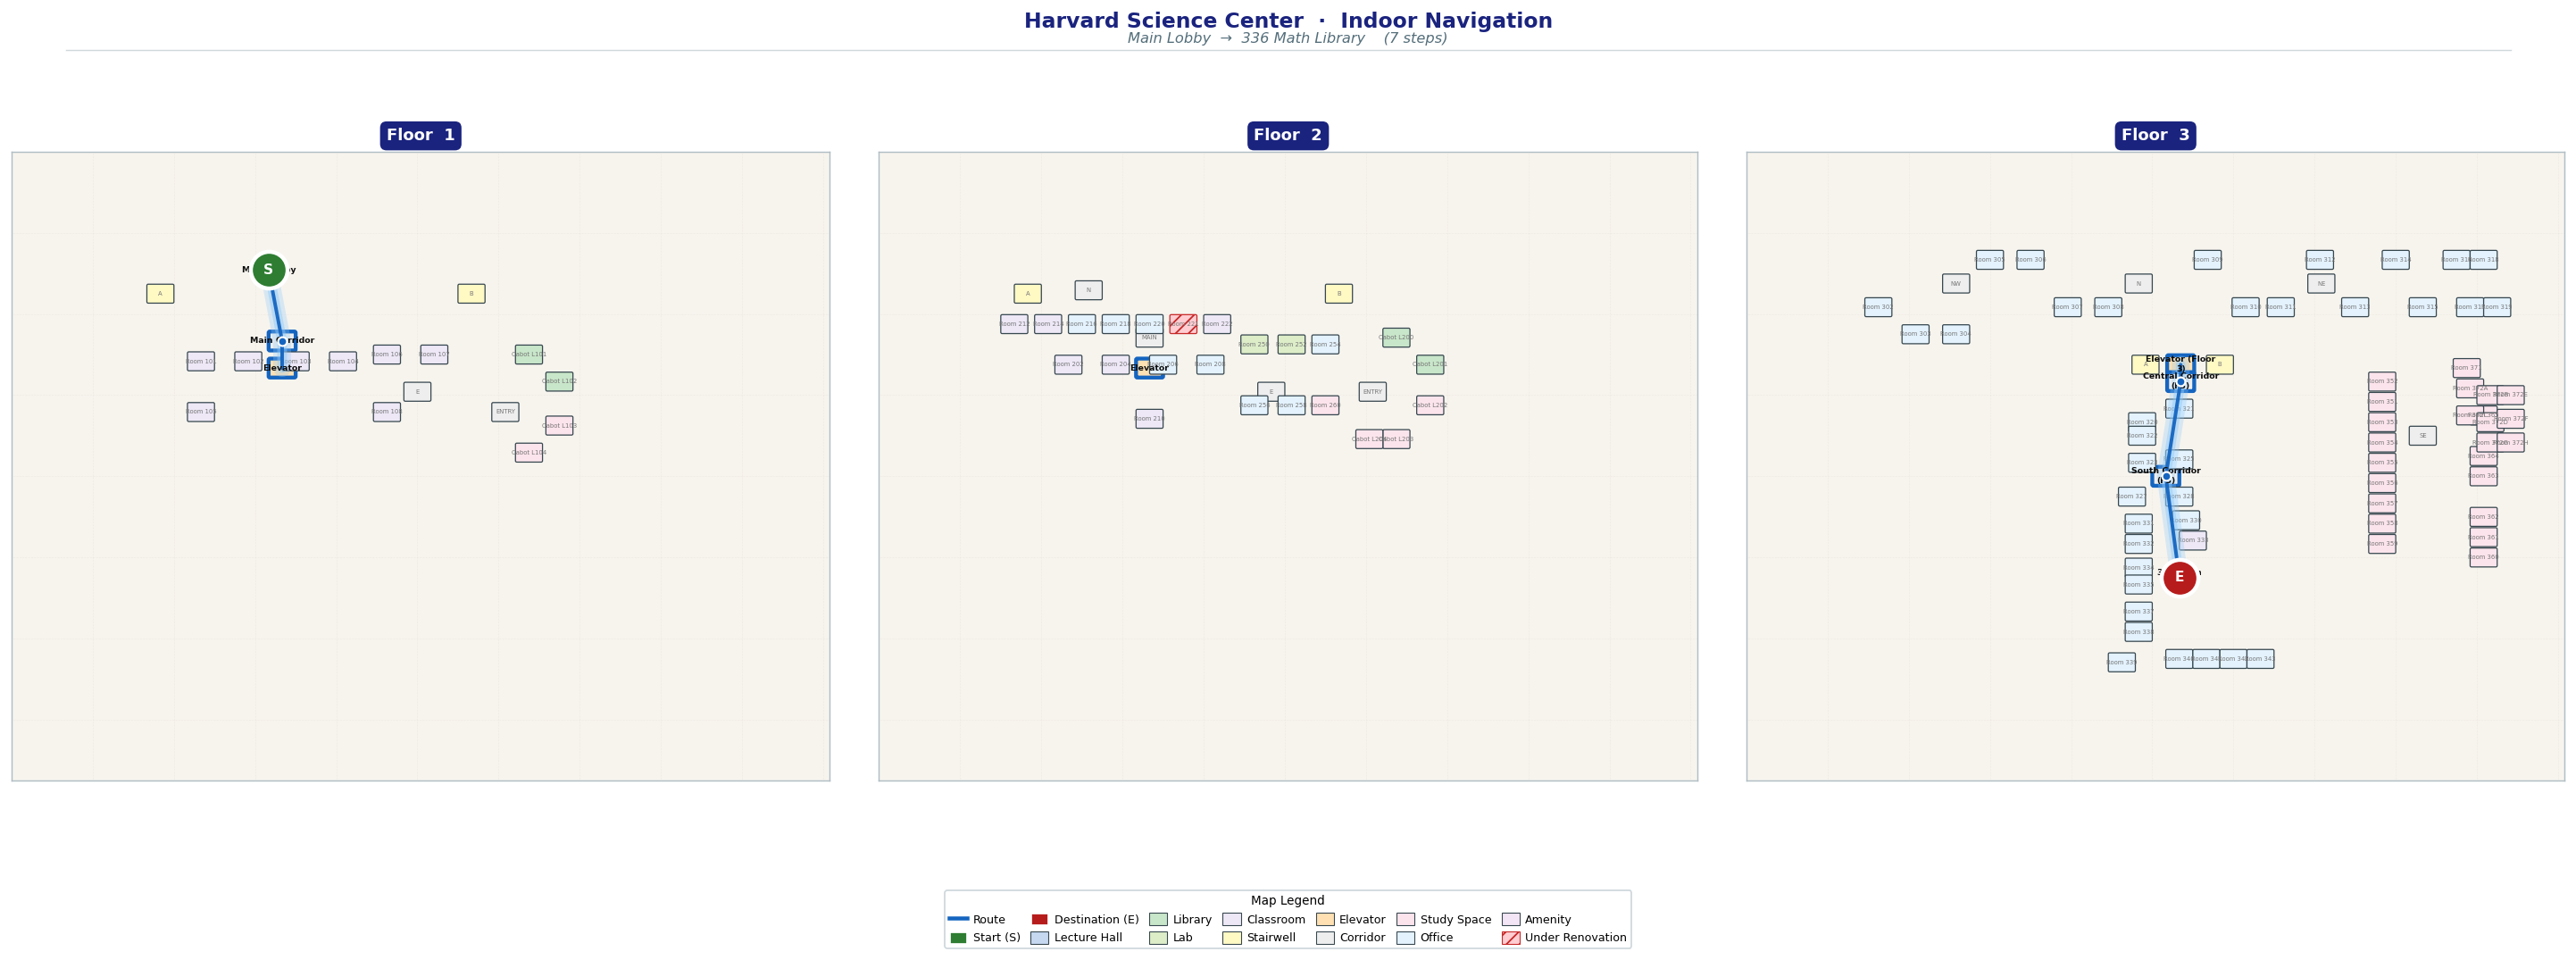


=== Path: sc-b-hall-a -> sc-505 (Basement Hall A to Floor 5) ===
  Hops: 11
sc-b-hall-a (Hall A, Floor 0) -> sc-b-hall-entry (Lecture Hall Entry, Floor 0) -> sc-b-corr-main (Main Corridor, Floor 0) -> sc-b-elev (Elevator, Floor 0) -> sc-1-elev (Elevator, Floor 1) -> sc-2-elev (Elevator, Floor 2) -> sc-3-elev (Elevator (Floor 3), Floor 3) -> sc-4-elev (Elevator (Floor 4), Floor 4) -> sc-5-elev (Elevator (Floor 5), Floor 5) -> sc-5-corridor-c (Central Corridor (F5), Floor 5) -> sc-5-corridor-s (South Corridor (F5), Floor 5) -> sc-505 (Room 505, Floor 5)


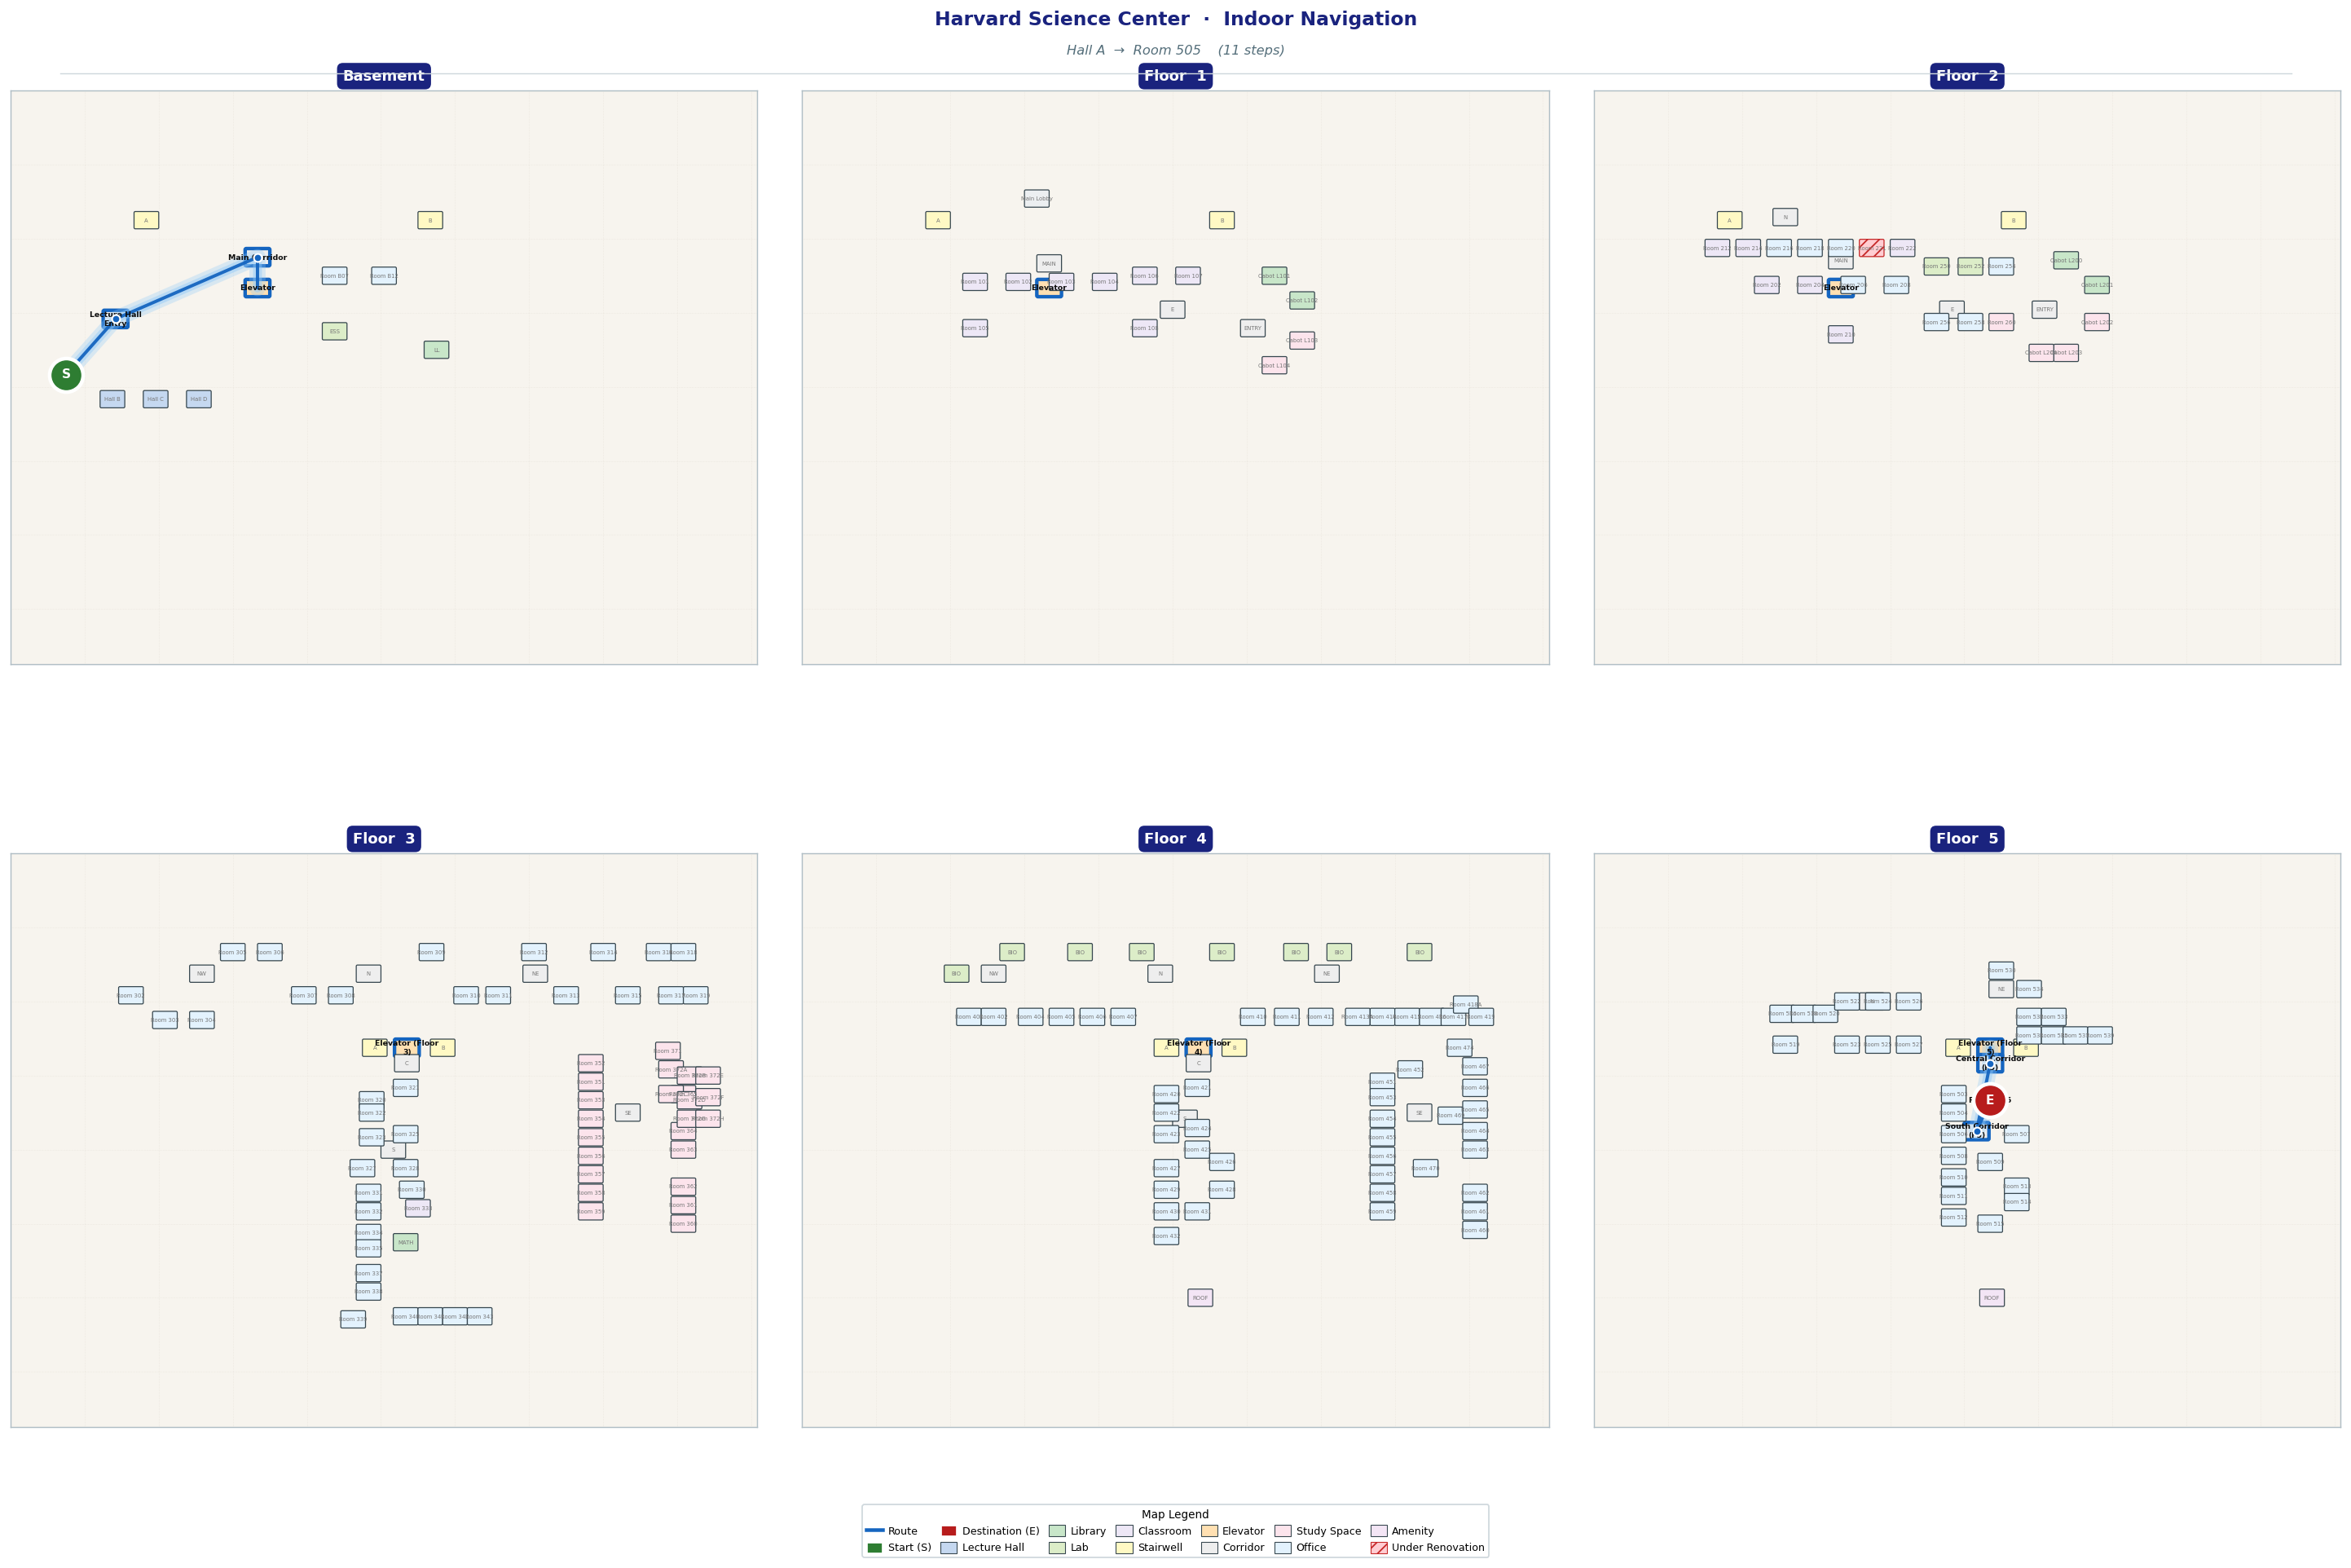


=== Path: navigating to sc-221 (under renovation) ===
  Caught expected error: Room 'sc-221' is under renovation and cannot be navigated to.


In [12]:
# === CELL C ===
# Section 2 demo queries against the Science Center room/type indexes

sc_room_index = build_room_index(SCIENCE_CENTER)
sc_type_index = build_type_index(SCIENCE_CENTER)

# ------------------------------------------------------------------
# Search demos
# ------------------------------------------------------------------

# 1. Search for "math library"
print_search_results(search_rooms("math library", sc_room_index, sc_type_index), "math library")

# 2. Search for "biology"
print_search_results(search_rooms("biology", sc_room_index, sc_type_index), "biology")

# 3. Search for "cabot" — all Cabot Library entries
print_search_results(search_rooms("cabot", sc_room_index, sc_type_index), "cabot")

# ------------------------------------------------------------------
# Path demos
# ------------------------------------------------------------------

# 4. Lobby (floor 1) -> Math Library (floor 3) — cross-floor
print("\n=== Path: sc-1-lobby -> sc-336-math (Lobby to Math Library) ===")
path_1 = find_path_sc("sc-1-lobby", "sc-336-math", sc_room_index)
print(f"  Hops: {len(path_1) - 1}")
print(pretty_print_path(path_1, sc_room_index))
visualize_path(path_1, sc_room_index, title="Lobby -> Math Library")

# 5. Hall A basement (floor B) -> Room 505 (floor 5) — maximum cross-floor test
print("\n=== Path: sc-b-hall-a -> sc-505 (Basement Hall A to Floor 5) ===")
path_2 = find_path_sc("sc-b-hall-a", "sc-505", sc_room_index)
print(f"  Hops: {len(path_2) - 1}")
print(pretty_print_path(path_2, sc_room_index))
visualize_path(path_2, sc_room_index, title="Basement Hall A -> Room 505")

# 6. Attempt to navigate to a room under renovation — expect ValueError
print("\n=== Path: navigating to sc-221 (under renovation) ===")
try:
    path_3 = find_path_sc("sc-1-lobby", "sc-221", sc_room_index)
except ValueError as e:
    print(f"  Caught expected error: {e}")


## 6. Video Script

**Video walkthrough (5 min):**

| Time | Content | Speaker |
|---|---|---|
| 0:00 – 0:30 | Introduction | Leon |
| 0:30 – 2:30 | Walk through `SAMPLE_BUILDING` and the search function output | Leon |
| 2:30 – 05:00| Walk through the BFS algorithm and its output cases | Arjun |